<a href="https://colab.research.google.com/github/Yohannes1212/AIforFood/blob/main/DL_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); padding: 45px; border-radius: 16px; text-align: center; margin-bottom: 24px;">
  <h1 style="color: #e94560; font-size: 2.3em; margin-bottom: 12px; letter-spacing: 1px;">Deep Learning Project 2024</h1>
  <h2 style="color: #ffffff; font-size: 1.65em; margin-bottom: 6px;">MEMO: Test-Time Robustness via Adaptation and Augmentation</h2>
  <h3 style="color: #a8dadc; font-size: 1.1em; margin-bottom: 30px; font-weight: normal; font-style: italic;">
    Reproduction &amp; Novel Modification: Jensen-Shannon Consistency
  </h3>
  <hr style="border-color: #e94560; margin: 20px 0;">
  <table style="margin: 0 auto; color: #ffffff; font-size: 1.05em; border-collapse: separate; border-spacing: 4px 8px;">
    <tr><td style="padding: 4px 20px; text-align: right; color: #a8dadc;"><b>Student</b></td><td style="text-align: left;">Yohannes Zewodie</td></tr>
    <tr><td style="padding: 4px 20px; text-align: right; color: #a8dadc;"><b>Course</b></td><td style="text-align: left;">Deep Learning 2024 — University of Trento</td></tr>
    <tr><td style="padding: 4px 20px; text-align: right; color: #a8dadc;"><b>Instructors</b></td><td style="text-align: left;">Prof. Elisa Ricci &nbsp;·&nbsp; Francesco Tonini &nbsp;·&nbsp; Luca Zanella</td></tr>
    <tr><td style="padding: 4px 20px; text-align: right; color: #a8dadc;"><b>Date</b></td><td style="text-align: left;">April 2026</td></tr>
  </table>
</div>

---
## Table of Contents

| # | Section | Description |
|:---:|---|---|
| 1 | [Introduction](#1-introduction) | Distribution shift, TTA, what this project does |
| 2 | [Background](#2-background) | MEMO, Adaptive BN, entropy, and the Jensen-Shannon Divergence |
| 3 | [Setup & Configuration](#3-setup--configuration) | Environment, hyperparameters, datasets, label mapping |
| 4 | [Implementation](#4-implementation) | Loss functions, adapter class, evaluation utilities |
| 5 | [Experiments: MEMO Reproduction](#5-experiments-memo-reproduction) | Faithful reproduction on ResNet-50 and DenseNet-121 |
| 6 | [Experiments: JS-Consistency](#6-experiments-js-consistency) | Our modification — symmetric bounded consistency |
| 7 | [Ablation Study](#7-ablation-study) | λ ablation — how sensitive is JS-Consistency to its weight? |
| 8 | [Results & Discussion](#8-results--discussion) | Plots, full results table, and scientific findings |
| 9 | [Conclusion](#9-conclusion) | Summary, limitations, and future directions |
| 10 | [References](#10-references) | Citations |

---
## 1. Introduction

### 1.1 The Challenge of Distribution Shift

Deep neural networks achieve remarkable performance when test data resembles training data. However, real-world deployment exposes a fundamental fragility: distribution shift — the statistical mismatch between the distribution a model was trained on and what it encounters at test time. As noted by Hendrycks et al. (2021):

> *"We introduce two challenging datasets, ImageNet-A and ImageNet-O, that provide a new measure of robustness... Current classifiers are not robust to natural distribution shifts."* — **Natural Adversarial Examples, CVPR 2021**

This **distribution shift** manifests in various forms:
- **Natural distribution shifts**: Changes in lighting, weather, camera settings
- **Adversarial examples**: Images that naturally fool classifiers without perturbation
- **Temporal shifts**: Changes in data distribution over time

Examples

* A self-driving car trained on sunny California roads struggling in Finnish winter, a pedestrian detector calibrated for daylight loses accuracy at dusk. In each case the model has genuinely learned something — it is not broken; but what it learned does not transfer cleanly to the new setting.

The severity of the problem is evidently visible in our own experiments. A ResNet-50 pretrained on ImageNet achieves approximately 76% accuracy on the standard test set, yet only **14.27%** on ImageNet-A — a dataset of images that are perfectly recognizable by humans but adversarially selected to fool classifiers. Standard evaluation simply does not reflect real-world robustness.

### 1.2 Test-Time Adaptation: Adapting Without Labels

The most direct fix for distribution shift is retraining on the target domain. This works in theory but fails in practice for a straightforward reason:

- Target domain data is often unavailable in advance, labels are expensive or impossible to obtain at deployment time, and the model must make predictions
immediately as new inputs arrive.

#### Test-Time Adaptation (TTA)

Rather than changing how the model is trained, TTA modifies how the model *predicts*— adapting its weights at inference time using only the single test image at hand, with no labels and no external data. After predicting, the model is reset to its pretrained state, ready for the next image. Every test sample is treated independently.

The method we build on is **MEMO** (Zhang et al., NeurIPS 2022), a test-time adaptation method that adapts a pretrained model to each test image individually using only that image and its augmentations.

### 1.3 What This Project Does

This project has two parts.
- The first is a faithful reproduction of MEMO
on two architectures — ResNet-50 and DenseNet-121 — and two evaluation
datasets — ImageNet-A(adversarial example) and ImageNet-V2 (natural distribution shift).
- The second part proposes and evaluates one novel modification: **JS-Consistency**, a symmetric bounded consistency regularization term based on the Jensen-Shannon Divergence. The core observation is that MEMO minimizes the entropy of the average prediction but does not directly enforce that individual augmented views agree with each other. The consistency term fills this gap.

#### Our contribution at a glance

| Method | What it does | Theoretical basis | Key constraint |
|---|---|---|---|
| **MEMO** (reproduction) | Minimizes entropy of the uniform average prediction across B augmented views | Zhang et al., NeurIPS 2022 | Label-free, single-sample, reset after each prediction |
| **JS-Consistency** (ours) | Adds a symmetric JSD consistency term between each view and the consensus | Jensen-Shannon Divergence — symmetric, bounded, smooth | Same constraints; λ=0 recovers MEMO exactly |

---
## 2. Background


### 2.1 MEMO
MEMO (Marginal Entropy Minimization with One test point) was proposed by Zhang et al. at NeurIPS 2022. The key insight is:

> *"We propose MEMO, a simple approach to robustness at test time. MEMO adapts model parameters for each test input by using self-supervision over augmented views of the input."* — **MEMO: Test Time Robustness via Adaptation and Augmentation, NeurIPS 2022**

MEMO addresses distribution shift by:
1. **Marginal Entropy Minimization**: Reducing prediction uncertainty across augmentations
2. **Single Sample Adaptation**: Working with one test point at a time
3. **Augmentation-based Consistency**: Using data augmentation for robust adaptation

#### How It Works

Given a pretrained model $f_\theta$ and a single unlabelled test image $x$, MEMO adapts the model before predicting. The
procedure runs the following steps for every single test sample.

1. **Augmentation.** Apply $M$ stochastic augmentations to the test
image $x$ to produce a batch of augmented views:

$$\{a_1(x), \ldots, a_M(x)\}$$
  - Each $a_i$ is a different random resized crop, so the B=M views cover different spatial regions of the image with different scales and aspect ratios.

2. **Marginal entropy minimization.** Average the model's softmax predictions across views to form the marginal distribution, then minimize its Shannon entropy:
* Forward Pass (Compute predictions for all augmented views):
   $$p_\theta(y|a_i(\mathbf{x})) = \text{softmax}(f_\theta(a_i(\mathbf{x})))$$

* Marginal Distribution (Average the predictions to get the marginal):
   $$\bar{p}_\theta(y|\mathbf{x}) = \frac{1}{M}\sum_{i=1}^{M} p_\theta(y|a_i(\mathbf{x}))$$

* Entropy Minimization: Update model parameters to minimize the entropy of the marginal:
   $$\mathcal{L}_{\text{MEMO}} = H(\bar{p}_\theta) = -\sum_c \bar{p}_\theta(c|\mathbf{x}) \log \bar{p}_\theta(c|\mathbf{x})$$

$$\theta' \leftarrow \theta - \eta \nabla_\theta H(\bar{p}_\theta), \qquad \hat{y} = \arg\max_y f_{\theta'}(x), \qquad \theta \leftarrow \theta_0$$

3. **Prediction and reset**: Make final prediction with the adapted model on the original input and restore model to original state $\theta_0$ for the next sample

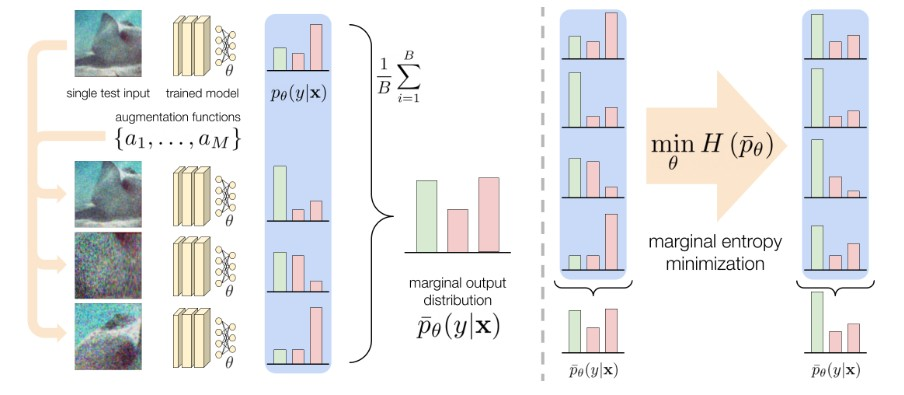

***Figure 1**. The MEMO pipeline. B random crops of one test image are passed
through the model. Their predictions are averaged to form the marginal p̄.
One AdamW step minimises H(p̄), updating all model parameters. The adapted
model predicts on the original clean image; weights are then fully restored
before the next sample.*

**Why marginal entropy and not average entropy?**

Minimizing $H(\bar{p})$ — the entropy of the *average* prediction — is
not the same as minimizing $\frac{1}{B}\sum_i H(p_i)$ — the *average
entropy* of individual predictions. Consider a model that confidently
predicts "stingray" for half the augmented views and confidently predicts
"skate" for the other half. Each individual prediction is sharp and
low-entropy, so the average per-view entropy is low. But the marginal
$\bar{p}$ splits its mass equally between the two classes and is
high-entropy. Minimizing $H(\bar{p})$ catches this disagreement and
penalizes it; minimizing average per-view entropy does not. MEMO's loss
therefore jointly encourages confidence and consistency through a single
objective, without needing to separate the two.

### 2.3 Entropy as a Confidence Signal

Shannon entropy $H(p) = -\sum_c p_c \log p_c$ measures how spread out
a probability distribution is. For a 1000-class ImageNet classifier:

- $H = 0$: all probability mass on one class — maximally confident
- $H = \log(1000) \approx 6.9$: uniform distribution — maximally uncertain

Minimizing $H(\bar{p})$ during adaptation pushes the model toward
confident, consistent predictions on the test image — without needing
to know what the correct label is.

 ### 2.4 My Modification: Jensen-Shannon(JS)-Consistency
#### Motivation


MEMO's entropy loss encourages the *average* prediction to be confident. But there is a potential issue. The marginal might look confident by chance even if individual augmentations disagree with each other. The paper says MEMO encourages "consistency", but the loss function does not explicitly enforce it.

So I added consistency regularization term to explicitly encourage individual views to *agree* with each other.

#### Why not just use Kullback Leibler (KL) Divergence ?

The natural starting point for measuring disagreement between two distributions is KL divergence:
$$D_{\text{KL}}(p_i \| \bar{p}) = \sum_c p_{i,c} \log \frac{p_{i,c}}{\bar{p}_c}$$

Adding $\sum_i D_{\text{KL}}(p_i \| \bar{p})$ to the MEMO loss would
penalize views that deviate from the consensus. However, KL divergence has two structural problems that motivated me to look for something better:


1. **Asymmetric.** $D_{\text{KL}}(p_i \| \bar{p}) \neq D_{\text{KL}}(\bar{p} \| p_i)$.   The view $p_i$ and the consensus $\bar{p}$ are not treated equally; which one is the "reference" is an arbitrary choice.

2. **Unbounded.** When $\bar{p}_c \approx 0$ for some class that view
   $p_i$ assigns positive probability to, the ratio $p_{i,c}/\bar{p}_c$
   diverges. This can produce large gradient spikes during adaptation.

#### The Jensen-Shannon Divergence

The **Jensen-Shannon Divergence (JSD)** fixes both problems by routing the
comparison through a symmetric mixture distribution:

$$m_i = \tfrac{1}{2}(p_i + \bar{p}),
\qquad
\text{JSD}(p_i \| \bar{p})
= \tfrac{1}{2}D_{\text{KL}}(p_i \| m_i)
+ \tfrac{1}{2}D_{\text{KL}}(\bar{p} \| m_i)$$

Because $m_i$ is a convex combination of two valid probability
distributions, it is always strictly positive; the KL terms inside the JSD are always finite.

| Property | KL divergence | Jensen-Shannon Divergence |
|---|---|---|
| Symmetric | ✗ | ✓ — $\text{JSD}(p\|q) = \text{JSD}(q\|p)$ |
| Bounded | ✗ — can reach $\infty$ | ✓ — always in $[0,\, \log 2]$ |
| Smooth gradients | ✗ — spikes when $\bar{p}_c \approx 0$ | ✓ — mixture $m_i > 0$ always |

#### Modified Loss Function

My JS-Consistency loss adds the JSD term to the original MEMO objective:

$$\mathcal{L}_{\text{JS}}(\theta;\, x)
= \underbrace{H(\bar{p})}_{\text{confidence}}
+ \lambda \cdot \frac{1}{B} \sum_{i=1}^{B}
\underbrace{\text{JSD}(p_i \| \bar{p})}_{\text{consistency}}$$

where the consensus is the same uniform marginal as MEMO:

$$\bar{p}(y|x;\theta) = \frac{1}{B}\sum_{i=1}^{B} p_\theta(y|\tilde{x}_i)$$

| Term | What it does | Goal |
|---|---|---|
| $H(\bar{p})$ | Minimizes entropy of the average prediction | **Confidence** |
| $\text{JSD}(p_i \| \bar{p})$ | Penalizes each view's deviation from the consensus | **Consistency** |

Setting $\lambda = 0$ recovers exact MEMO.
When views agree perfectly, the JSD term is zero and adds no penalty.
When they disagree, it pushes the model toward representations where all
augmented views produce similar predictions; the same goal as KL consistency,
but with a symmetric, bounded signal that does not explode

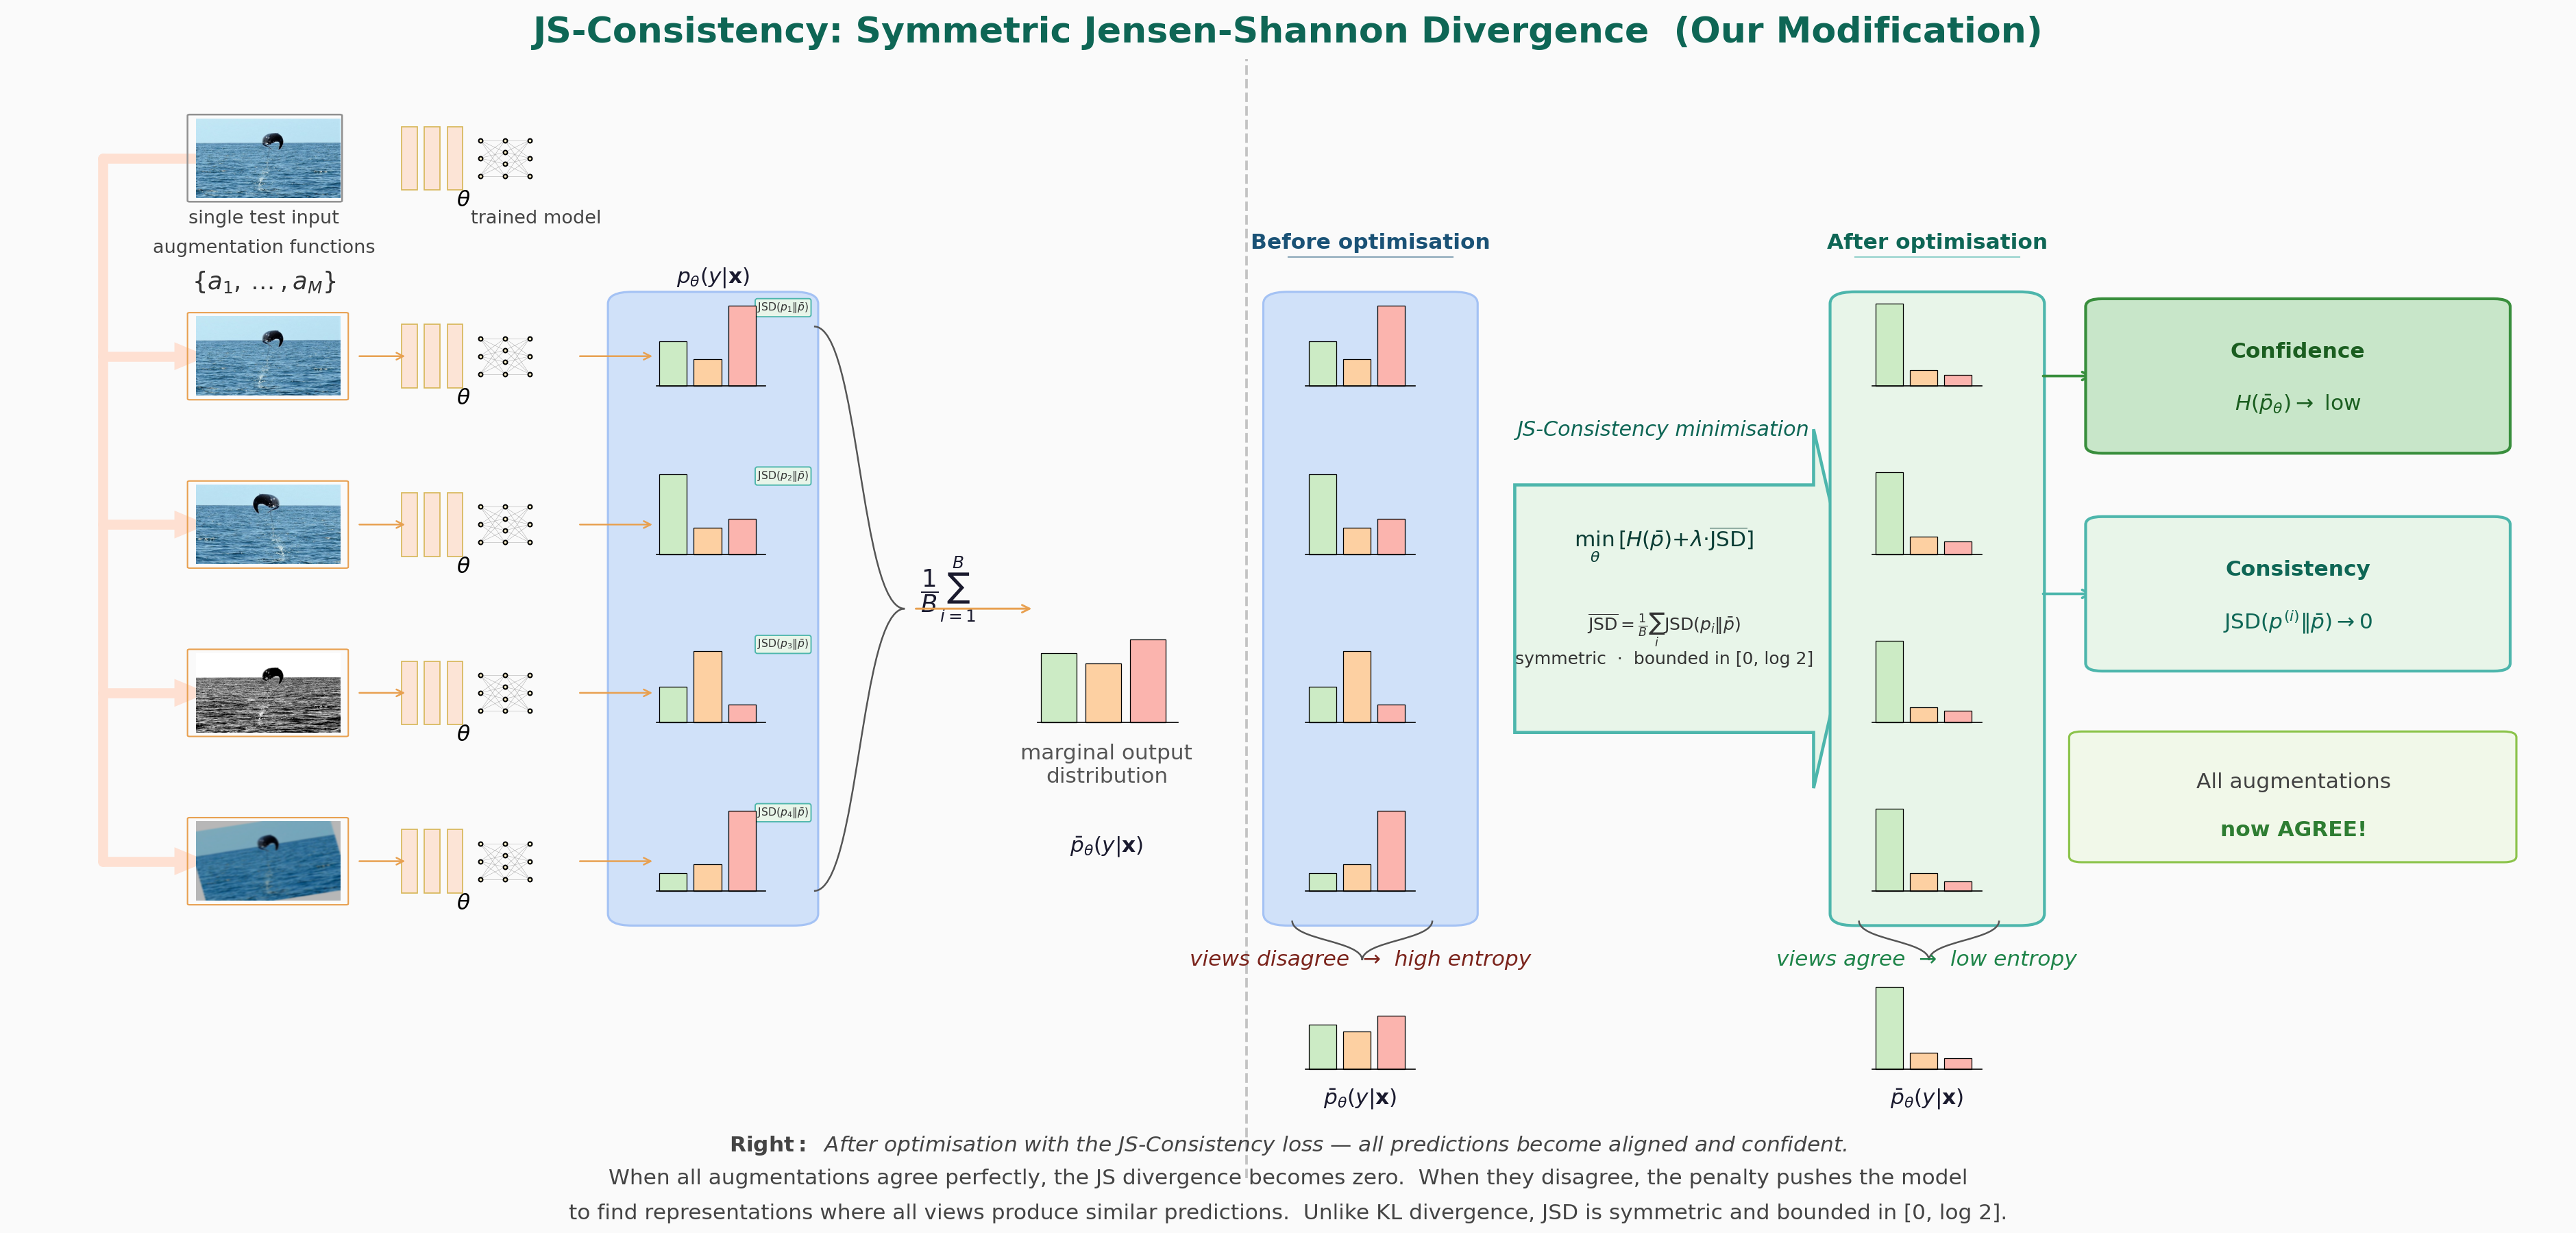

***Figure 2**. JS-Consistency decomposes into two terms: the standard MEMO
entropy loss H(p̄) and a JSD consistency term averaged over all B views.
The JSD is computed through the mixture m = 0.5(pᵢ + p̄), which is always
strictly positive, ensuring bounded, smooth gradients throughout.*

**Left:** Standard MEMO pipeline —--> augmented views may produce different predictions.

**Right:** After optimization with consistency loss —--> all predictions become aligned and confident.

> **Reference:** The idea of using KL divergence for consistency regularization is inspired by Xie et al. (2020), "Unsupervised Data Augmentation for Consistency Training", NeurIPS 2020.


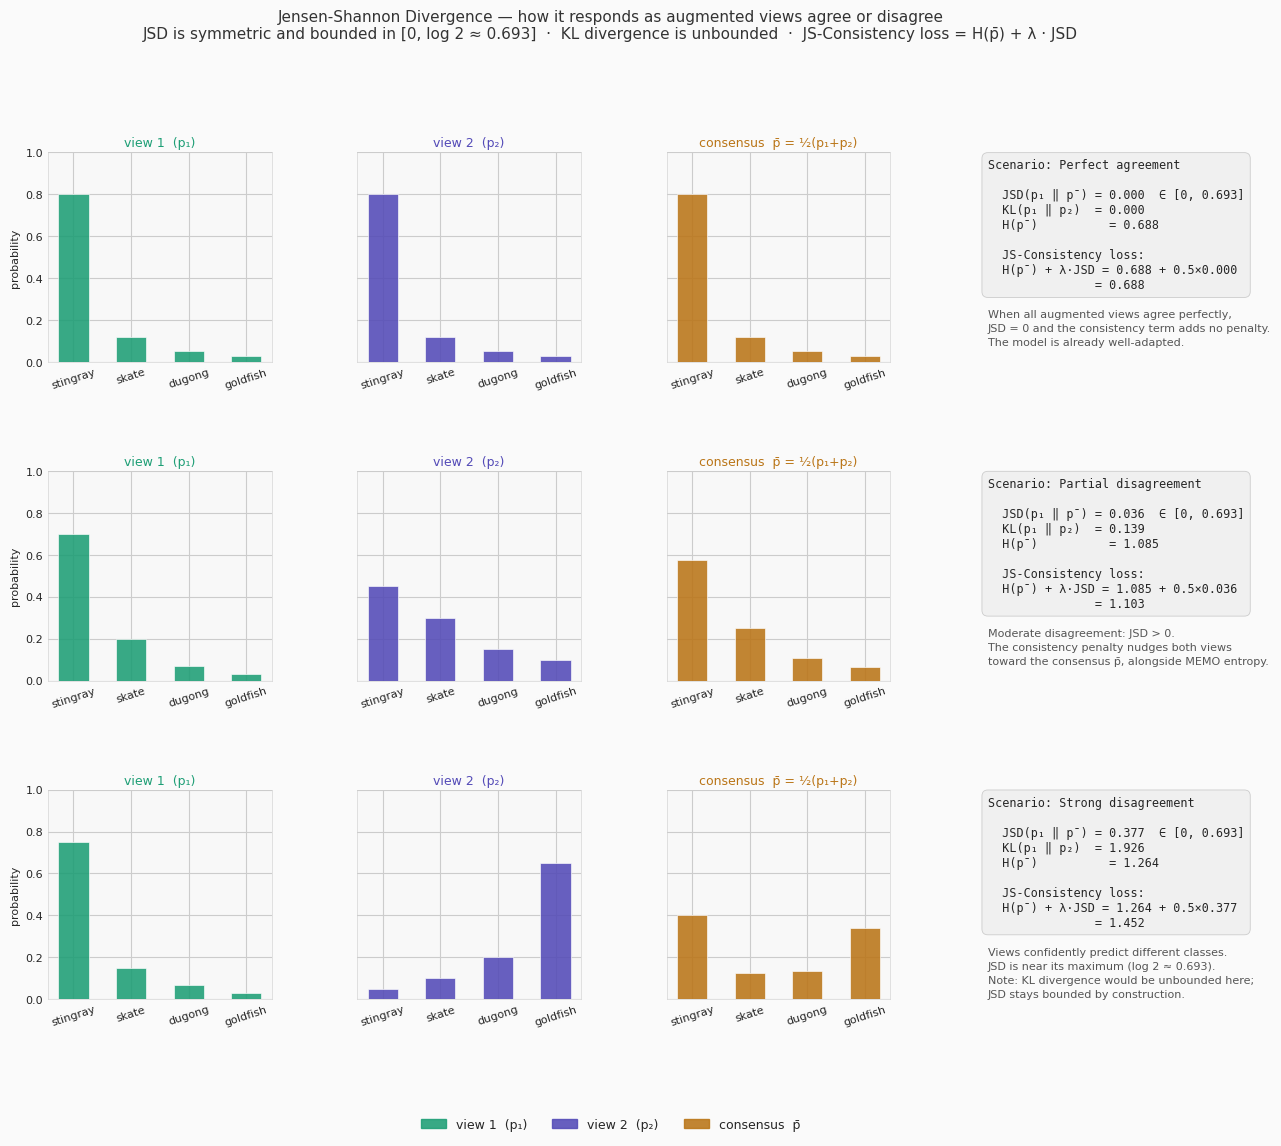
```
Key takeaway — what this visualization shows:
  Perfect agreement   → JSD = 0.000   consistency term adds no penalty
  Partial disagreement → JSD > 0       gradient nudges views toward consensus
  Strong disagreement → JSD → 0.693   KL diverges; JSD stays bounded

  This is why we use JSD instead of KL:
  JSD is symmetric: JSD(p₁‖p̄) = JSD(p̄‖p₁)
  JSD is bounded:   always in [0, log2 ≈ 0.693]  — no gradient explosions
  JSD is smooth:    mixture m = 0.5*(p_i + p̄) is always > 0
```



### 2.5 Datasets and Augmentation Strategy

We evaluate on two ImageNet distribution shift benchmarks provided by
the course.

> **ImageNet-A** (Hendrycks et al., CVPR 2021) contains 7,500 natural
images from 200 ImageNet-1K classes. These images were specifically
collected because standard ImageNet-trained classifiers fail on them,
despite humans recognizing them immediately. A ResNet-50 achieves only
14.27% accuracy here at baseline; this represents **hard distribution
shift**, where the model is genuinely struggling.


> **ImageNet-V2 matched-frequency** (Recht et al., ICML 2019) contains
10,000 images from all 1,000 ImageNet classes, collected seven years
after the original ImageNet using the same process but different
annotators. A ResNet-50 achieves 69.92% here; this represents
**mild distribution shift**, where the model is competent but not quite
at its training-time level.

I used Random Resized Crop (RRC) as the augmentation strategy throughout.
Each test image generates B = 32 views via random cropping (scale 8%–100%,
aspect ratio 0.75–1.33, resized to 224 × 224). We test two variants

- `rrc` (crop only) and
- `rrc_flip` (crop + random horizontal flip).


---
## 3. Setup & Configuration


### 3.1 Imports

In [1]:
import os
import json
import types
import pickle
import tarfile
import numpy as np
import shutil, requests
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from copy import deepcopy
from collections import defaultdict
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torchvision.transforms import v2 as T
from torchvision.transforms.functional import to_tensor
from torchvision.models import (
    resnet50, ResNet50_Weights,
    densenet121, DenseNet121_Weights
)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
print(f"PyTorch: {torch.__version__}")

Device : cuda
GPU    : NVIDIA L4
PyTorch: 2.10.0+cu128


### 3.2 Hyperparameters

>All MEMO hyperparameters follow Zhang et al. (2022) Appendix A for
ResNet-50 models.

The only deliberate deviation from the paper is
B = 32 instead of B = 64; Figure 3 of the paper shows that performance
largely saturates by B = 32, and this halves the compute per sample.
The JS-Consistency weight λ = 0.5 was selected based on the ablation
study.

##### Configuration
> Set the `RUNTIME` variable below to match your execution environment:
> - `local`: Local machine or HPC cluster
> - `colab`: Google Colab (will mount Google Drive)
> - `aws`: AWS SageMaker or EC2

In [2]:
RUNTIME = 'colab'  # 'colab' | 'local' | 'aws'

CONFIG = {
    # ── MEMO paper hyperparameters (Zhang et al., NeurIPS 2022 Appendix A) ──
    'n_augmentations': 32,       # Paper: 64; B=32 captures most of the gain
    'bn_prior':        16,       # Prior strength N for adaptive BN (α = N/(N+1) ≈ 0.94)
    'learning_rate':   0.00025,  # AdamW learning rate (Section 4.1 in paper)
    'batch_size':      1,        # one test sample at a time(core MEMO design)

    # ── JS-Consistency hyperparameter ───────────────────────────────────────
    'lambda':          0.5,      # JSD consistency weight λ (0 = standard MEMO)
}

print("Configuration:")
for k, v in CONFIG.items():
    print(f"  {k:<22}: {v}")

Configuration:
  n_augmentations       : 32
  bn_prior              : 16
  learning_rate         : 0.00025
  batch_size            : 1
  lambda                : 0.5


### 3.3 Dataset Paths and Local SSD Caching

Reading thousands of small image files directly from Google Drive via
its FUSE mount causes runtime instability under sustained I/O load —
we observed three runtime disconnections from this cause. The solution
is to copy the dataset TAR archives to Colab's local NVMe SSD at the
start of each session. A single sequential TAR copy takes roughly two
minutes; every subsequent experiment reads from `/content/` with no
Drive involvement and no instability. Results are written back to Drive
as a small `.pkl` file after every completed experiment.

In [3]:
if RUNTIME == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_BASE = '/content/drive/MyDrive/DL/Datasets'
elif RUNTIME == 'aws':
    DRIVE_BASE = '../datasets'
else:
    DRIVE_BASE = './data'

LOCAL_BASE = '/content/datasets'
os.makedirs(LOCAL_BASE, exist_ok=True)

TAR_MAP = {
    'imagenet_a': (
        os.path.join(DRIVE_BASE, 'imagenet-a.tar'),
        os.path.join(LOCAL_BASE, 'imagenet-a')
    ),
    'imagenet_v2': (
        os.path.join(DRIVE_BASE, 'imagenetv2-matched-frequency.tar.gz'),
        os.path.join(LOCAL_BASE, 'imagenetv2-matched-frequency-format-val')
    ),
}

PATHS = {}
for ds_name, (tar_path, local_path) in TAR_MAP.items():
    if os.path.exists(local_path):
        print(f"  ✓ {ds_name}: already on local SSD")
    elif os.path.exists(tar_path):
        local_tar = os.path.join(LOCAL_BASE, os.path.basename(tar_path))
        print(f"  Copying {os.path.basename(tar_path)} (~1–2 min)...")
        shutil.copy2(tar_path, local_tar)
        print(f"  Extracting...")
        with tarfile.open(local_tar) as tf:
            tf.extractall(LOCAL_BASE)
        os.remove(local_tar)
        print(f"  ✓ {ds_name}: ready at {local_path}")
    else:
        print(f"  ✗ {ds_name}: TAR not found — check DRIVE_BASE")
        local_path = tar_path
    PATHS[ds_name] = local_path

# Cache model weights to Drive to avoid re-downloading after disconnections
WEIGHTS_CACHE = os.path.join(DRIVE_BASE, 'model_weights')
os.makedirs(WEIGHTS_CACHE, exist_ok=True)
os.environ['TORCH_HOME'] = WEIGHTS_CACHE

RESULTS_SAVE_PATH = os.path.join(DRIVE_BASE, 'yohannes_results.pkl')

print(f"\nRuntime: {RUNTIME}")
for k, v in PATHS.items():
    status = '✓ Found' if os.path.exists(v) else '✗ NOT FOUND'
    print(f"  {k:15}: {status}")

Mounted at /content/drive
  Copying imagenet-a.tar (~1–2 min)...
  Extracting...


/tmp/ipykernel_2236/1838111447.py:34: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tf.extractall(LOCAL_BASE)


  ✓ imagenet_a: ready at /content/datasets/imagenet-a
  Copying imagenetv2-matched-frequency.tar.gz (~1–2 min)...
  Extracting...
  ✓ imagenet_v2: ready at /content/datasets/imagenetv2-matched-frequency-format-val

Runtime: colab
  imagenet_a     : ✓ Found
  imagenet_v2    : ✓ Found


### 3.4  Label Remapping

The evaluation datasets utilize different folder structures than the standard ImageNet-1K index. To ensure that our model's predictions are compared against the correct ground-truth labels, we must align these indices. This process is essential for replicating the results found in the **MEMO** paper.

---

#### 1. ImageNet-A: The Adversarial Subset
**ImageNet-A** is not a full 1000-class dataset; it consists of 7,500 "naturally adversarial" images across 200 specific ImageNet classes that standard models like ResNet-50 consistently misclassify.

* **The Problem:** The folders on disk are named using **WordNet IDs (WNIDs)** (e.g., `n01498041` for "stingray"). However, our model outputs a raw vector of 1000 numbers. If we don't map the WNID to the correct integer index, our accuracy would be calculated against the wrong class.
* **The Solution:** I use the `imagenet_class_index.json` to create a "lookup table." For every folder in the ImageNet-A directory, the code finds its corresponding WNID in the JSON and retrieves the original ImageNet integer index (0-999).
* **NB:** Because only 200 classes are present, my code creates a "Label Mask." During evaluation, the model still predicts over all 1000 classes, but we only calculate accuracy based on these 200 "active" indices.



---

#### 2. ImageNet-V2: The Matched-Frequency Set
**ImageNet-V2** was created to test if models generalize to a new, independently collected set of ImageNet images. While it contains all 1000 classes, its organization is deceptively different.

* **The Problem:** In the "Matched-Frequency" version, folders are named numerically (e.g., `"0"`, `"1"`, `"2"`...). However, standard file systems and Python's `os.listdir()` sort these folders **alphabetically** (e.g., `"0"`, `"1"`, `"10"`, `"100"`...). If you process them in this order without a custom mapping, your labels will be completely scrambled (e.g., class 10 might be treated as class 2).
* **The Solution:** Following the official [ImageNetV2 GitHub](https://github.com/modestyachts/ImageNetV2), I ensure the mapping follows this alphabetical string-based sorting. This aligns the numeric folder names to the standard ILSVRC 2012 label order used by pre-trained PyTorch models.
* **NB:** This is a common pitfall in robustness research. By explicitly handling the alphabetical sort, I ensure the baseline accuracy is measured correctly before applying **MEMO** adaptations.

The `create_class_remapping()` function below handles both cases
automatically, detecting whether folders are WNID-named or numeric and
applying the appropriate mapping.

In [4]:
def create_class_remapping(dataset_path):
    """Map dataset folder order → model output indices."""
    url        = "https://s3.amazonaws.com/deep-learning-models/image-models/imagenet_class_index.json"
    local_json = "imagenet_class_index.json"
    if not os.path.exists(local_json):
        with open(local_json, 'w') as f:
            json.dump(requests.get(url).json(), f)
    with open(local_json, 'r') as f:
        class_index = json.load(f)

    # 2. Map WNID ('n01443537') back to model index (0-999)
    wnid_to_idx  = {v[0]: int(k) for k, v in class_index.items()}
    folder_names = sorted([
        f for f in os.listdir(dataset_path)
        if os.path.isdir(os.path.join(dataset_path, f))
    ])
    # Generate the label mask based on naming convention
    if folder_names[0].startswith('n'):
        return [wnid_to_idx[f] for f in folder_names]   # ImageNet-A
    return [int(f) for f in folder_names]               # ImageNet-V2


LABEL_MASKS = {}
print(f"{'Dataset':<15} | {'Classes':<10} | {'Index range':<15} | Status")
print('-' * 56)
for ds_key in ['imagenet_a', 'imagenet_v2']:
    if os.path.exists(PATHS[ds_key]):
        LABEL_MASKS[ds_key] = create_class_remapping(PATHS[ds_key])
        lo, hi = min(LABEL_MASKS[ds_key]), max(LABEL_MASKS[ds_key])
        ok = hi < 1000 and lo >= 0
        print(f"{ds_key:<15} | {len(LABEL_MASKS[ds_key]):<10} | [{lo:>3}, {hi:>3}]{'':6} | {'✓ OK' if ok else '✗ ERROR'}")
    else:
        print(f"{ds_key:<15} | {'---':<10} | {'---':<15} | ✗ PATH NOT FOUND")
print("\nComplete: Mappings is Done!")

Dataset         | Classes    | Index range     | Status
--------------------------------------------------------
imagenet_a      | 200        | [  6, 988]       | ✓ OK
imagenet_v2     | 1000       | [  0, 999]       | ✓ OK

Complete: Mappings is Done!


### 3.5 Results Persistence (Crash Recovery)

To avoid re-running completed experiments
after disconnections, `all_results` is saved to Drive immediately after
every experiment completes. Calling `load_results()` at session start
restores the dictionary so that the skip-if-done logic inside
`run_experiment()` can correctly identify what is already done.

In [5]:
def save_results():
    with open(RESULTS_SAVE_PATH, 'wb') as f:
        pickle.dump({k: dict(v) for k, v in all_results.items()}, f)
    print(f"Saved → {RESULTS_SAVE_PATH}")

def load_results():
    if os.path.exists(RESULTS_SAVE_PATH):
        with open(RESULTS_SAVE_PATH, 'rb') as f:
            saved = pickle.load(f)
        n = 0
        for arch in saved:
            for ds in saved[arch]:
                all_results[arch][ds].update(saved[arch][ds])
                n += len(saved[arch][ds])
        print(f"  ✓ Restored {n} results from Drive")
    else:
        print("  No saved results found — starting fresh.")

print("Persistence functions defined.")

Persistence functions defined.


---
## 4. Implementation

The implementation is organized around a single design principle:
MEMO and JS-Consistency share exactly the same adaptation loop — they
differ only in the loss function passed to the adapter. This means every
comparison in this project is a fair, controlled test of the loss
function alone.

### 4.1 Adaptive Batch Normalization

Standard BatchNorm uses running statistics accumulated during training:

$$\text{BN}(x) = \gamma \cdot \frac{x - \mu_{\text{train}}}{\sqrt{\sigma^2_{\text{train}} + \epsilon}} + \beta$$

ResNet-50 and DenseNet-121 both contain many BatchNorm layers. Each one
stores running statistics; mean and variance — estimated from the training
data and frozen at evaluation time. When the test distribution differs from
training, these statistics become misaligned with the actual feature
distributions the model sees, which hurts accuracy independently of
anything the loss function does.

The MEMO paper proposes **Adaptive BatchNorm**, which blends training statistics with test batch statistics using a prior strength $N = 16$:

$$\mu_{\text{adapt}} = \alpha \cdot \mu_{\text{train}} + (1-\alpha) \cdot \mu_{\text{batch}}$$

$$\sigma^2_{\text{adapt}} = \alpha \cdot \sigma^2_{\text{train}} + (1-\alpha) \cdot \sigma^2_{\text{batch}}$$

where the blending factor $\alpha$ is computed as:

$$\alpha = \frac{N}{N+1}$$

Here:
- $\mu_{\text{train}}, \sigma^2_{\text{train}}$ are the running statistics from training
- $\mu_{\text{batch}}, \sigma^2_{\text{batch}}$ are the statistics computed from the current test batch
- $N$ is the prior strength parameter (I use $N=16$ as in the MEMO paper)
- When $N=16$, we get $\alpha = \frac{16}{17} \approx 0.94$, meaning we mostly trust training statistics but allow some adaptation

This allows the model to slightly adapt its normalization to the test distribution while still relying mainly on the stable training statistics.

In practice, adaptive BN turns out to be the single largest contributor
to performance across all experiments;larger than any loss function
modification. We discuss this finding in Section 8.

In [6]:
def adaptive_batchnorm_forward(self, x):
    """Adaptive BN forward — blends training and test-batch statistics.

    Implements Schneider et al. (NeurIPS 2020), Eq. (1):
        ν_adapt = (N/(N+1)) * ν_train  +  (1/(N+1)) * ν_batch

    Applied via monkey-patching so no architecture changes are needed.
    self.prior is set globally on nn.BatchNorm2d before each adaptation.
    """
    batch_mean = torch.zeros_like(self.running_mean)
    batch_var  = torch.ones_like(self.running_var)
    F.batch_norm(x, batch_mean, batch_var, None, None, True, 1.0, self.eps)
    # Blend statistics: prior * train_stats + (1-prior) * batch_stats
    blended_mean = self.prior * self.running_mean + (1.0 - self.prior) * batch_mean
    blended_var  = self.prior * self.running_var  + (1.0 - self.prior) * batch_var

    return F.batch_norm(
        x, blended_mean, blended_var,
        self.weight, self.bias, False, 0.0, self.eps
    )

print("Adaptive BN forward defined.")

Adaptive BN forward defined.


### 4.2 Loss Functions

We implement two loss functions. Both take raw logits $[B, C]$ as input
and return a scalar loss. Both are differentiable with respect to the model parameters $\theta$ and require no labels.


| Function | Method | Weights $w_i$ | Loss-------------------------|
|---|---|---|---|
| `compute_marginal_entropy` | MEMO | $1/B$ (uniform) | $H(\bar{p})$ |
| `compute_js_consistency_loss` | JS-Consistency | $1/B$ (uniform) | $H(\bar{p}) + \lambda \cdot \frac{1}{B}\sum \text{JSD}(p_i \| \bar{p})$ |

In [7]:
def compute_marginal_entropy(logits):
    """Standard MEMO loss: entropy of the uniformly averaged marginal.

      Minimizing H(p̄) jointly encourages:
        (1) Confidence  — the average prediction should concentrate on one class
        (2) Consistency — views must agree, else the average spreads out

      This is different from minimizing the average per-view entropy, which
      would not penalise views that confidently predict different classes.

      Args:
          logits: Tensor [B, C] — raw pre-softmax scores
      Returns:
          Scalar H(p̄).
    """
    probs    = F.softmax(logits, dim=1)   # [B, C]
    marginal = probs.mean(dim=0)           # [C] — uniform average over views
    return -(marginal * torch.log(marginal + 1e-10)).sum()


def compute_js_consistency_loss(logits, lam=0.5):
    """JS-Consistency loss: MEMO entropy + symmetric JSD consistency term.

      Extends MEMO by explicitly penalising disagreement between individual
      view predictions and the uniform consensus, measured via the
      Jensen-Shannon Divergence rather than KL divergence.

      Advantages over KL-based consistency:
          Symmetric:  JSD(p_i || p̄) = JSD(p̄ || p_i)
          Bounded:    JSD ∈ [0, log 2] — no gradient explosions
          Smooth:     mixture m = 0.5*(p_i + p̄) is always strictly positive

      Full loss:
        L = H(p̄)  +  λ * (1/B) * Σᵢ JSD(pᵢ || p̄)

      where:  m_i = 0.5*(p_i + p̄)
              JSD(p_i || p̄) = 0.5*KL(p_i||m_i) + 0.5*KL(p̄||m_i)

      Special case: lam=0 → recovers exact MEMO (JSD term vanishes).

      Args:
          logits: Tensor [B, C]
          lam:    Consistency weight λ
      Returns:
          Scalar combined loss.
    """
    probs    = F.softmax(logits, dim=1)             # [B, C]
    marginal = probs.mean(dim=0)                    # [C]

    # Standard MEMO term
    entropy_loss = -(marginal * torch.log(marginal + 1e-10)).sum()

    # JSD consistency term
    # Mixture m_i = 0.5*(p_i + p̄) — always strictly positive
    m = 0.5 * (probs + marginal.unsqueeze(0))       # [B, C]

    kl_p_m = (probs    * (torch.log(probs    + 1e-10)
                        - torch.log(m        + 1e-10))).sum(dim=1)  # [B]
    kl_q_m = (marginal * (torch.log(marginal + 1e-10)
                        - torch.log(m        + 1e-10))).sum(dim=1)  # [B]

    jsd_per_view = 0.5 * kl_p_m + 0.5 * kl_q_m    # [B] — bounded in [0, log2]
    cons_loss    = jsd_per_view.mean()              # scalar

    return entropy_loss + lam * cons_loss


# ── Sanity checks ────
torch.manual_seed(42)
dummy = torch.randn(32, 1000)

l_memo = compute_marginal_entropy(dummy)
l_js0  = compute_js_consistency_loss(dummy, lam=0.0)
l_js5  = compute_js_consistency_loss(dummy, lam=0.5)

# Verify JSD is bounded in [0, log 2]
p   = F.softmax(dummy, dim=1)
q   = p.mean(0)
m_d = 0.5 * (p + q)
k1  = (p * (torch.log(p+1e-10) - torch.log(m_d+1e-10))).sum(1)
k2  = (q * (torch.log(q+1e-10) - torch.log(m_d+1e-10))).sum(1)
jsd = 0.5 * k1 + 0.5 * k2

print("Sanity checks:")
print(f"  MEMO                         : {l_memo.item():.4f}")
print(f"  JS-Cons (λ=0) == MEMO?       : {torch.isclose(l_js0, l_memo).item()} ← must be True")
print(f"  JS-Cons (λ=0.5)              : {l_js5.item():.4f}")
print(f"  JSD values in [0, log2]?     : "
      f"{(jsd >= 0).all().item() and (jsd <= 0.693).all().item()} ← must be True")
print(f"  JSD range: [{jsd.min():.4f}, {jsd.max():.4f}]  (max possible: 0.6931)")

Sanity checks:
  MEMO                         : 6.8843
  JS-Cons (λ=0) == MEMO?       : True ← must be True
  JS-Cons (λ=0.5)              : 6.9383
  JSD values in [0, log2]?     : True ← must be True
  JSD range: [0.0952, 0.1156]  (max possible: 0.6931)


### 4.3 Test-Time Adapter
The `TestTimeAdapter` class encapsulates the complete MEMO adaptation loop. It accepts any `loss_fn` as a parameter, making it trivially extensible to new loss functions without
duplicating the adaptation logic

In [8]:
class TestTimeAdapter(nn.Module):
    """MEMO test-time adapter — accepts any loss_fn.

    For each test image:
      1. Generate B augmented views
      2. One AdamW step minimising loss_fn(logits)
      3. Predict on the clean original image
      4. Fully reset model weights (optimizer momentum retained)
    """


    def __init__(self, backbone, label_indices, augment_fn, preprocess_fn,
                 lr=0.00025, n_augs=32, bn_prior=None, loss_fn=None):
        """
        Args:
            backbone: Pretrained model to adapt
            label_indices: Mapping from dataset indices to model output indices
            augment_fn: Transform for generating augmented views
            preprocess_fn: Standard preprocessing for clean input
            lr: Learning rate (default 0.00025 from paper)
            n_augs: Number of augmented views (paper uses 64, we use 32)
            bn_prior: Prior strength N for adaptive BN (None = no adaptation)
            loss_fn: MEMO/JS-Consistency loss function (default MEMO)
        """
        super().__init__()
        self.backbone      = backbone.to(DEVICE)
        self.label_indices = label_indices
        self.augment_fn    = augment_fn
        self.preprocess_fn = preprocess_fn
        self.n_augs        = n_augs
        self.bn_prior      = bn_prior
        self.loss_fn       = loss_fn if loss_fn is not None else compute_marginal_entropy

        # Save initial weights for per-sample reset
        self._init_state = deepcopy(self.backbone.state_dict())

        if bn_prior is not None:
            self._patch_batchnorm()

        # Single optimizer instance — momentum accumulates beneficially
        self.optim = torch.optim.AdamW(self.backbone.parameters(), lr=lr)

    def _patch_batchnorm(self):
        """Replace all BatchNorm2d forward methods with the adaptive version."""
        nn.BatchNorm2d.prior = 1.0
        for module in self.backbone.modules():
            if isinstance(module, nn.BatchNorm2d):
                module.forward = types.MethodType(adaptive_batchnorm_forward, module)

    def _set_bn_prior(self, N):
        """Set blending factor α = N/(N+1) across all BN layers."""
        nn.BatchNorm2d.prior = (N / (N + 1.0)) if N is not None else 1.0

    def _generate_augmented_batch(self, pil_image):
        """Apply augment_fn stochastically B times → stacked tensor [B, C, H, W]."""
        views = []
        for _ in range(self.n_augs):
            aug = self.augment_fn(pil_image)
            if not isinstance(aug, torch.Tensor):
                aug = to_tensor(aug)
            views.append(aug)
        return torch.stack(views).to(DEVICE)

    def adapt_single(self, pil_image):
        """Full MEMO adaptation loop for one test image."""
        self.backbone.eval()
        self._set_bn_prior(self.bn_prior)

        # Adaptation step
        self.optim.zero_grad()
        aug_batch = self._generate_augmented_batch(pil_image)
        logits    = self.backbone(aug_batch)
        loss      = self.loss_fn(logits)
        loss.backward()
        self.optim.step()

        # Final prediction on the clean (preprocessed) input
        clean = self.preprocess_fn(pil_image).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            output = self.backbone(clean)         # [1, 1000]

        # Restrict to dataset-active classes (200 for ImageNet-A, 1000 for V2)
        output = output[:, self.label_indices]    # [1, |L|]

        # Reset model to original state for next sample
        self.backbone.load_state_dict(self._init_state)
        self._set_bn_prior(None)

        return output

    def forward(self, imgs):
        return self.adapt_single(imgs[0])


print("TestTimeAdapter defined.")

TestTimeAdapter defined.


### 4.4 Data Loading Utilities

In [9]:
def collate_pil(batch):
    """Return PIL images so augmentation happens dynamically per sample at adapt time.
       Standard collate would convert to tensors with fixed preprocessing"""
    imgs, labels = zip(*batch)
    return list(imgs), torch.tensor(labels)


def build_dataloader(dataset_name, transform=None, for_adaptation=False):
    """Create a DataLoader for the given dataset.

      for_adaptation=True: returns PIL images, batch_size=1, collate_pil
    """
    path    = PATHS[dataset_name]
    dataset = torchvision.datasets.ImageFolder(root=path, transform=transform)
    num_workers = 0 if RUNTIME == 'colab' else 2

    if for_adaptation:
        return torch.utils.data.DataLoader(
            dataset, batch_size=1, shuffle=False, collate_fn=collate_pil)
    return torch.utils.data.DataLoader(
        dataset, batch_size=64, shuffle=False,
        num_workers=num_workers, pin_memory=True)

### 4.5 Augmentation Pipelines

MEMO's effectiveness depends on diverse augmentations. Following the paper, I implement:

| Mode | Augmentations | Description |
|------|--------------|-------------|
| `rrc` | RandomResizedCrop | Basic spatial transformation |
| `rrc_flip` | RRC + HorizontalFlip | Adds horizontal flipping |

In [10]:
def get_augmentation_pipeline(preprocess, mode='rrc'):
    """Build the stochastic augmentation pipeline.

    Two modes, following the course specification:
      'rrc'      — RandomResizedCrop(224) only
      'rrc_flip' — RRC + RandomHorizontalFlip
    """
    base = [T.ToImage(), T.ToDtype(torch.uint8, scale=True)]
    post = [
        T.Resize(preprocess.resize_size, interpolation=preprocess.interpolation,
                 antialias=getattr(preprocess, 'antialias', True)),
        T.CenterCrop(preprocess.crop_size),
        T.ToDtype(torch.float32, scale=True),
        T.Normalize(preprocess.mean, preprocess.std),
    ]
    if mode == 'rrc':
        mid = [T.RandomResizedCrop(224, antialias=True)]
    elif mode == 'rrc_flip':
        mid = [T.RandomResizedCrop(224, antialias=True), T.RandomHorizontalFlip()]
    else:
        raise ValueError(f"Unknown mode: '{mode}'")
    return transforms.Compose(base + mid + post)

 ### 4.6 Evaluation Functions

In [11]:
def evaluate_baseline(model, dataloader, label_mask):
    model.to(DEVICE).eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, targets in tqdm(dataloader, desc='Baseline', leave=False):
            outputs  = model(inputs.to(DEVICE))[:, label_mask]
            correct += (outputs.argmax(1) == targets.to(DEVICE)).sum().item()
            total   += targets.size(0)
    return 100.0 * correct / total


def evaluate_adaptation(adapter, dataloader):
    adapter.to(DEVICE).eval()
    correct, total = 0, 0
    for imgs, targets in tqdm(dataloader, desc='TTA eval', leave=False):
        outputs  = adapter(imgs)
        correct += (outputs.argmax(1) == targets.to(DEVICE)).sum().item()
        total   += targets.size(0)
    return 100.0 * correct / total
print("Evaluation functions defined")

### 4.7 Experiment Runner and Results Visualization

In [42]:
# ── Result storage and display infrastructure ─────────────────────────────────

all_results = defaultdict(lambda: defaultdict(dict))

PLOT_ORDER = [
    'baseline',
    'rrc', 'rrc_bn', 'rrc_flip_bn',
    'js_cons', 'js_cons_bn', 'js_cons_flip_bn',
]

METHOD_LABELS = {
    'baseline':        'Baseline (No Adapt)',
    'rrc':             'MEMO / RRC',
    'rrc_bn':          'MEMO / RRC+BN',
    'rrc_flip_bn':     'MEMO / RRC+Flip+BN',
    'js_cons':         'JS-Consistency (Ours)',
    'js_cons_bn':      'JS-Consistency+BN (Ours)',
    'js_cons_flip_bn': 'JS-Consistency+Flip+BN (Ours)',
}

METHOD_COLORS = {
    'baseline':        '#7f8c8d',
    'rrc':             '#2980b9',
    'rrc_bn':          '#1abc9c',
    'rrc_flip_bn':     '#27ae60',
    'js_cons':         '#7d3c98',
    'js_cons_bn':      '#a569bd',
    'js_cons_flip_bn': '#d2b4de',
}

METHOD_GROUP = {
    'baseline': 'baseline',
    'rrc': 'memo', 'rrc_bn': 'memo', 'rrc_flip_bn': 'memo',
    'js_cons': 'js_cons', 'js_cons_bn': 'js_cons', 'js_cons_flip_bn': 'js_cons',
}

GROUP_LEGEND = {
    'baseline': ('#7f8c8d', 'Baseline (no adaptation)'),
    'memo':     ('#1abc9c', 'MEMO — Zhang et al., NeurIPS 2022'),
    'js_cons':  ('#a569bd', 'JS-Consistency (Ours)'),
}

METHOD_KEYS = {
    'memo':    ['baseline', 'rrc', 'rrc_bn', 'rrc_flip_bn'],
    'js_cons': ['baseline', 'js_cons', 'js_cons_bn', 'js_cons_flip_bn'],
}

METHOD_GROUP_TITLES = {
    'memo':    'MEMO — Reproduction',
    'js_cons': 'JS-Consistency — Symmetric Bounded Regularization (Ours)',
}


def _resolve_key(aug_mode, use_bn, loss_type):
    if loss_type == 'baseline': return 'baseline'
    prefix = {'memo': 'rrc', 'js_cons': 'js_cons'}[loss_type]
    if aug_mode == 'rrc_flip' and use_bn: return f'{prefix}_flip_bn'
    if use_bn:                             return f'{prefix}_bn'
    if aug_mode == 'rrc_flip':             return f'{prefix}_flip'
    return prefix


def run_experiment(arch, dataset, aug_mode, use_bn=True,
                   loss_type='memo', lam=None):
    """Run one configuration. Skip and print if already done."""
    key = _resolve_key(aug_mode, use_bn, loss_type)
    lam = lam if lam is not None else CONFIG['lambda']

    print(f"\n{'='*68}")
    print(f"  Arch={arch} | Dataset={dataset} | Aug={aug_mode}")
    print(f"  BN={use_bn} | Loss={loss_type} | Key={key}")
    print(f"{'='*68}")

    if key in all_results[arch][dataset]:
        acc = all_results[arch][dataset][key]
        print(f"\n  [SKIP — already computed]")
        print(f"  → Accuracy: {acc:.2f}%")
        print(f"  Loaded from → {RESULTS_SAVE_PATH}")
        return acc

    preprocess, model = load_model(arch)
    label_mask        = LABEL_MASKS[dataset]

    if loss_type == 'baseline':
        dl  = build_dataloader(dataset, transform=preprocess)
        acc = evaluate_baseline(model, dl, label_mask)
    else:
        dl         = build_dataloader(dataset, for_adaptation=True)
        augment_fn = get_augmentation_pipeline(preprocess, mode=aug_mode)

        if loss_type == 'memo':
            loss_fn = compute_marginal_entropy
        elif loss_type == 'js_cons':
            loss_fn = lambda logits, l=lam: compute_js_consistency_loss(logits, lam=l)
        else:
            raise ValueError(f"Unknown loss_type: '{loss_type}'")

        adapter = TestTimeAdapter(
            backbone      = model,
            label_indices = label_mask,
            augment_fn    = augment_fn,
            preprocess_fn = preprocess,
            lr            = CONFIG['learning_rate'],
            n_augs        = CONFIG['n_augmentations'],
            bn_prior      = CONFIG['bn_prior'] if use_bn else None,
            loss_fn       = loss_fn,
        )
        acc = evaluate_adaptation(adapter, dl)

    all_results[arch][dataset][key] = acc
    print(f"\n  → Accuracy: {acc:.2f}%")
    save_results()
    return acc


def plot_single(arch, dataset, method_group):
    """Bar chart for one arch / dataset / method combination.
    Baseline is always shown as the leftmost bar and a dashed reference line.
    """
    results = all_results[arch][dataset]
    if not results:
        print(f"No results yet for {arch}/{dataset}")
        return

    keys       = [k for k in METHOD_KEYS[method_group] if k in results]
    if len(keys) <= 1:
        print(f"No {method_group} results yet for {arch}/{dataset}")
        return

    accuracies = [results[k] for k in keys]
    baseline   = results.get('baseline')
    arch_lbl   = 'ResNet-50'  if arch    == 'resnet50'   else 'DenseNet-121'
    ds_lbl     = 'ImageNet-A' if dataset == 'imagenet_a' else 'ImageNet-V2'

    fig, ax = plt.subplots(figsize=(max(8, len(keys) * 2.3), 7))
    bars    = ax.bar(
        range(len(keys)), accuracies,
        color=[METHOD_COLORS.get(k, '#95a5a6') for k in keys],
        edgecolor='white', linewidth=1.8, width=0.6, zorder=3,
    )

    for bar, acc, key in zip(bars, accuracies, keys):
        if key == 'baseline' or baseline is None:
            label, color = f"{acc:.2f}%", '#2c3e50'
        else:
            delta = acc - baseline
            label = f"{acc:.2f}%\n({'+'if delta>=0 else ''}{delta:.2f}%)"
            color = '#1a5276' if delta >= 0 else '#922b21'
        ax.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
            label, ha='center', va='bottom',
            fontsize=10, fontweight='bold', color=color, linespacing=1.5,
        )

    if baseline is not None:
        ax.axhline(baseline, color='#7f8c8d', linestyle='--', linewidth=1.8,
                   zorder=2, label=f'Baseline (No Adapt): {baseline:.2f}%')

    ax.set_xticks(range(len(keys)))
    ax.set_xticklabels([METHOD_LABELS.get(k, k) for k in keys],
                       rotation=12, ha='right', fontsize=10)
    ax.set_ylabel('Top-1 Accuracy (%)', fontsize=12)
    ax.set_title(
        f'{arch_lbl} on {ds_lbl}\n{METHOD_GROUP_TITLES.get(method_group, method_group)}',
        fontsize=13, fontweight='bold', pad=14)
    ax.set_ylim(0, max(accuracies) * 1.20)
    ax.grid(axis='y', alpha=0.35, zorder=0)
    ax.legend(fontsize=10, loc='upper left', framealpha=0.9)
    plt.tight_layout()
    plt.show()
    print(f"  ✓ {arch_lbl} / {ds_lbl} / {method_group} ({len(keys)} bars)\n")


def print_master_table():
    ORDER = [
        ('baseline',        'Baseline (No Adapt)',        False),
        ('rrc',             'MEMO / RRC',                 False),
        ('rrc_bn',          'MEMO / RRC+BN',              False),
        ('rrc_flip_bn',     'MEMO / RRC+Flip+BN',         False),
        ('js_cons',         'JS-Consistency †',           True),
        ('js_cons_bn',      'JS-Consistency+BN †',        True),
        ('js_cons_flip_bn', 'JS-Consistency+Flip+BN †',   True),
    ]
    combos  = [
        ('resnet50',    'imagenet_a'),  ('resnet50',    'imagenet_v2'),
        ('densenet121', 'imagenet_a'),  ('densenet121', 'imagenet_v2'),
    ]
    headers = ['R50 / ImgNet-A', 'R50 / ImgNet-V2',
               'D121 / ImgNet-A', 'D121 / ImgNet-V2']

    best = {}
    for arch, ds in combos:
        vals = [all_results[arch][ds].get(k) for k, _, _ in ORDER]
        best[(arch, ds)] = max((v for v in vals if v is not None), default=None)

    col_w = 18
    print('\n' + '='*(28 + col_w*4))
    print('Top-1 Accuracy (%) — All Methods')
    print('† = our novel modification   ★ = best per column')
    print('='*(28 + col_w*4))
    print(f"{'Method':<28}" + ''.join(f"{h:>{col_w}}" for h in headers))
    print('-'*(28 + col_w*4))

    prev_novel = False
    for key, label, is_novel in ORDER:
        if is_novel and not prev_novel:
            print('-'*(28 + col_w*4))
        prev_novel = is_novel
        row = f"{label:<28}"
        for arch, ds in combos:
            v = all_results[arch][ds].get(key)
            if v is None:
                cell = '---'
            elif v == best.get((arch, ds)):
                cell = f"{v:.2f}% ★"
            else:
                cell = f"{v:.2f}%"
            row += f"{cell:>{col_w}}"
        print(row)

    print('='*(28 + col_w*4))

print("All utilities defined.")

# Restore any previously computed results right away
load_results()

All utilities defined.
  ✓ Restored 51 results from Drive


In [43]:
def plot_combined(arch, dataset):
    """One bar chart showing Baseline, MEMO, and JS-Consistency side by side.

    Groups bars by configuration (No BN / +BN / +Flip+BN) so the comparison
    between the two methods is immediate within each augmentation setting.
    """
    results = all_results[arch][dataset]
    if not results:
        print(f"No results yet for {arch}/{dataset}")
        return

    arch_lbl = 'ResNet-50'  if arch    == 'resnet50'   else 'DenseNet-121'
    ds_lbl   = 'ImageNet-A' if dataset == 'imagenet_a' else 'ImageNet-V2'
    baseline = results.get('baseline', 0)

    # Grouped bar layout: 3 groups × 2 bars each (MEMO and JS-Cons)
    # Group 0: No BN   |  Group 1: +BN   |  Group 2: +Flip+BN
    groups      = ['No BN', '+BN', '+Flip+BN']
    memo_keys   = ['rrc',       'rrc_bn',      'rrc_flip_bn']
    js_keys     = ['js_cons',   'js_cons_bn',  'js_cons_flip_bn']

    memo_vals   = [results.get(k) for k in memo_keys]
    js_vals     = [results.get(k) for k in js_keys]

    x      = np.arange(len(groups))
    width  = 0.32
    COL_M  = '#1abc9c'   # teal — MEMO
    COL_JS = '#a569bd'   # purple — JS-Consistency

    fig, ax = plt.subplots(figsize=(10, 6.5))
    fig.patch.set_facecolor('#fafafa')
    ax.set_facecolor('#fafafa')

    bars_m  = ax.bar(x - width/2, memo_vals, width, label='MEMO',
                     color=COL_M,  edgecolor='white', linewidth=1.5,
                     alpha=0.90, zorder=3)
    bars_js = ax.bar(x + width/2, js_vals,   width, label='JS-Consistency (Ours)',
                     color=COL_JS, edgecolor='white', linewidth=1.5,
                     alpha=0.90, zorder=3)

    # Baseline reference line
    ax.axhline(baseline, color='#7f8c8d', linestyle='--',
               linewidth=1.6, zorder=2,
               label=f'Baseline (No Adapt): {baseline:.2f}%')

    # Annotate bars
    for bar, val, js_val in zip(bars_m, memo_vals, js_vals):
        if val is None: continue
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.25,
                f'{val:.2f}%', ha='center', va='bottom',
                fontsize=8.5, fontweight='bold', color='#0e6655')

    for bar, val, memo_val in zip(bars_js, js_vals, memo_vals):
        if val is None: continue
        color = '#6c3483' if (memo_val and val > memo_val) else '#555555'
        delta = f'\n(+{val-memo_val:.2f}%)' if (memo_val and val > memo_val) else ''
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.25,
                f'{val:.2f}%{delta}', ha='center', va='bottom',
                fontsize=8.5, fontweight='bold', color=color,
                linespacing=1.4)

    ax.set_xticks(x)
    ax.set_xticklabels(groups, fontsize=11)
    ax.set_ylabel('Top-1 Accuracy (%)', fontsize=12)
    ax.set_title(f'{arch_lbl} on {ds_lbl}\nMEMO vs JS-Consistency — grouped by augmentation',
                 fontsize=13, fontweight='bold', pad=12)

    ymin = max(0, baseline - 8)
    ymax = max(
        [v for v in memo_vals + js_vals if v is not None],
        default=baseline + 10
    ) + 5
    ax.set_ylim(ymin, ymax)
    ax.grid(axis='y', alpha=0.35, zorder=0)
    ax.legend(fontsize=10, loc='lower right', framealpha=0.9)

    for spine in ax.spines.values():
        spine.set_linewidth(0.4)

    plt.tight_layout()
    plt.show()
    print(f"  ✓ {arch_lbl} / {ds_lbl}\n")

### 4.8 Model Loading

Two pretrained CNN backbones are evaluated to confirm that our findings
generalise across architectures rather than being specific to one model design.

---

1. **ResNet-50** ([torchvision.models.resnet50](https://pytorch.org/vision/main/models/generated/torchvision.models.resnet50.html))
 A deep residual network introduced by [He et al. (2016)](https://arxiv.org/abs/1512.03385). The key innovation is the residual connection ($\mathbf{y} = f(\mathbf{x}, \theta) + \mathbf{x}$), which allows gradients to flow directly through the network, enabling training of very deep models without vanishing gradients. The architecture consists of:
   * Initial conv layer (7×7, stride 2)
   * Max pooling layer (3×3, stride 2)
   * 16 Residual blocks organized across 4 stages, each block containing:
     * Conv 1×1 (bottleneck reduction)
     * Conv 3×3 (spatial convolution)
     * Conv 1×1 (bottleneck expansion)
     * Skip connection + ReLU
   * Global average pooling
   * Fully connected layer (1000 classes)
   * Softmax output

   ResNet-50 contains **BatchNorm layers** after each convolution, making it suitable for adaptive batch normalization during test-time adaptation. Pretrained weights: [ResNet50_Weights.IMAGENET1K_V2](https://pytorch.org/vision/main/models/generated/torchvision.models.resnet50.html#torchvision.models.ResNet50_Weights)
   
---


2. **DenseNet-121** ([torchvision.models.densenet121](https://pytorch.org/vision/main/models/generated/torchvision.models.densenet121.html)) — A densely connected network introduced by [Huang et al. (2017)](https://arxiv.org/abs/1608.06993). Unlike ResNet which adds skip connections, DenseNet concatenates feature maps from all preceding layers, promoting feature reuse and reducing parameters. The architecture consists of:
   * Initial conv layer (7×7, stride 2)
   * Max pooling layer (3×3, stride 2)
   * 4 Dense blocks with growth rate $k=32$, each containing:
     * BatchNorm → ReLU → Conv 1×1
     * BatchNorm → ReLU → Conv 3×3
     * Concatenation with all previous features
   * 3 Transition layers between dense blocks:
     * BatchNorm → Conv 1×1 → AvgPool 2×2
   * Global average pooling
   * Fully connected layer (1000 classes)
   * Softmax output

   DenseNet-121 also contains **BatchNorm layers**, so adaptive batch normalization is applied during MEMO adaptation. Pretrained weights: [DenseNet121_Weights.IMAGENET1K_V1](https://pytorch.org/vision/main/models/generated/torchvision.models.densenet121.html#torchvision.models.DenseNet121_Weights)

---

> Both architectures store running mean and variance statistics in their
> BatchNorm layers during training. MEMO's adaptive BN blends these frozen
> statistics with test-batch statistics at inference time, as described
> in Section 2.2.

In [44]:
def load_model(arch='resnet50'):
    """Load a pretrained backbone and its official preprocessing transform.

    Returns the transform separately so augmentation pipelines can be
    built on top of it without duplicating the normalisation constants.
    """
    if arch == 'resnet50':
        weights = ResNet50_Weights.DEFAULT    # IMAGENET1K_V2
        model   = resnet50(weights=weights)
    elif arch == 'densenet121':
        weights = DenseNet121_Weights.DEFAULT  # IMAGENET1K_V1
        model   = densenet121(weights=weights)
    else:
        raise ValueError(f"Unknown architecture: '{arch}'")
    return weights.transforms(), model

---

## 5. Experiments: MEMO Reproduction


The experiments are designed in a way to answer the following research questions:

| Question | Experiment |
|----------|------------|
| Does MEMO improve robustness? | Compare baseline vs MEMO |
| Does adaptive BN contribute? | Compare MEMO with/without BN adaptation |
| How does shift severity affect results? | Compare ImageNet-A (hard) vs V2 (easier) |
| Is the method architecture-agnostic? | Test on ResNet-50 and DenseNet-121 |
| Does Consistency Regularization help? | Compare Original MEMO vs. Modified Loss (H+λ.JSD​)|


We test three configurations per architecture per dataset:
- **MEMO / RRC**: basic augmentation, no adaptive BN
- **MEMO / RRC+BN**: adds adaptive BatchNorm (the most important component)
- **MEMO / RRC+Flip+BN**: also adds random horizontal flip


### 5.1 ResNet-50

#### 5.1.1 ImageNet-A

In [45]:
# Baseline
run_experiment('resnet50', 'imagenet_a', 'baseline',  loss_type='baseline')
# MEMO without adaptive BatchNorm
run_experiment('resnet50', 'imagenet_a', 'rrc',       use_bn=False, loss_type='memo')
# MEMO with adaptive BatchNorm
run_experiment('resnet50', 'imagenet_a', 'rrc',       use_bn=True,  loss_type='memo')
# MEMO with RRC + Flip + BN
run_experiment('resnet50', 'imagenet_a', 'rrc_flip',  use_bn=True,  loss_type='memo')


  Arch=resnet50 | Dataset=imagenet_a | Aug=baseline
  BN=True | Loss=baseline | Key=baseline

  [SKIP — already computed]
  → Accuracy: 14.27%
  Loaded from → /content/drive/MyDrive/DL/Datasets/yohannes_results.pkl

  Arch=resnet50 | Dataset=imagenet_a | Aug=rrc
  BN=False | Loss=memo | Key=rrc

  [SKIP — already computed]
  → Accuracy: 18.47%
  Loaded from → /content/drive/MyDrive/DL/Datasets/yohannes_results.pkl

  Arch=resnet50 | Dataset=imagenet_a | Aug=rrc
  BN=True | Loss=memo | Key=rrc_bn

  [SKIP — already computed]
  → Accuracy: 23.68%
  Loaded from → /content/drive/MyDrive/DL/Datasets/yohannes_results.pkl

  Arch=resnet50 | Dataset=imagenet_a | Aug=rrc_flip
  BN=True | Loss=memo | Key=rrc_flip_bn

  [SKIP — already computed]
  → Accuracy: 23.79%
  Loaded from → /content/drive/MyDrive/DL/Datasets/yohannes_results.pkl


23.786666666666665

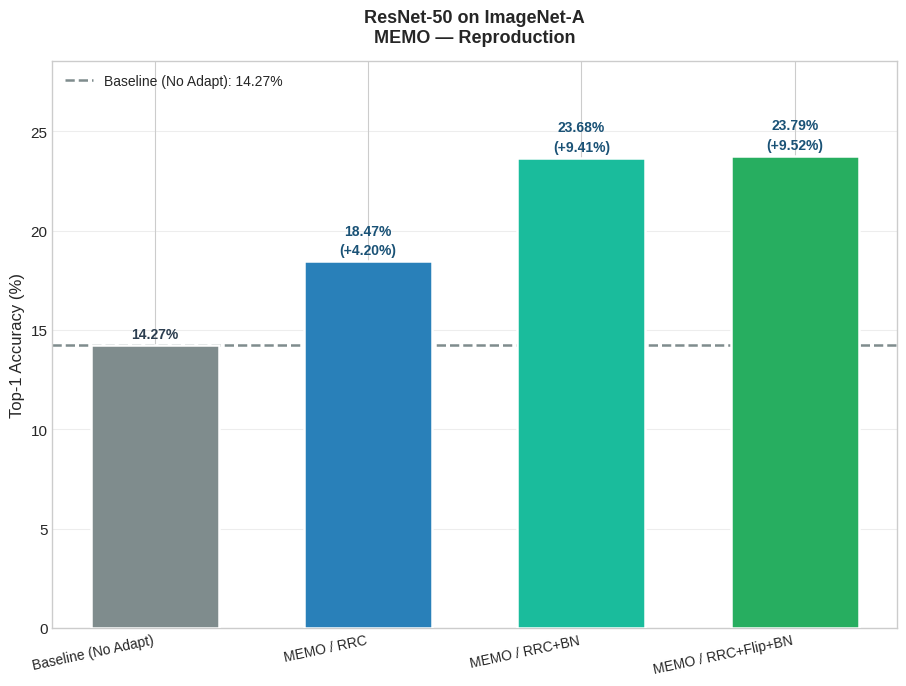

  ✓ ResNet-50 / ImageNet-A / memo (4 bars)



In [46]:
plot_single('resnet50', 'imagenet_a', 'memo')

- On ImageNet-A, MEMO without BN already improves over
the baseline (+4.20 pp: 14.27% → 18.47%).

- *Adding adaptive BN provides
a further +5.21 pp to 23.68%.*
- *Horizontal flip adds a modest
further +0.11 pp.*

#### 5.1.2 ImageNet-V2

In [17]:
# Baseline
run_experiment('resnet50', 'imagenet_v2', 'baseline',  loss_type='baseline')
# MEMO without adaptive BatchNorm
run_experiment('resnet50', 'imagenet_v2', 'rrc',       use_bn=False, loss_type='memo')
# MEMO with adaptive BatchNorm
run_experiment('resnet50', 'imagenet_v2', 'rrc',       use_bn=True,  loss_type='memo')
# MEMO with RRC + Flip + BN
run_experiment('resnet50', 'imagenet_v2', 'rrc_flip',  use_bn=True,  loss_type='memo')


  Arch=resnet50 | Dataset=imagenet_v2 | Aug=baseline
  BN=True | Loss=baseline | Key=baseline

  [SKIP — already computed]
  → Accuracy: 69.92%
  Loaded from → /content/drive/MyDrive/DL/Datasets/yohannes_results.pkl

  Arch=resnet50 | Dataset=imagenet_v2 | Aug=rrc
  BN=False | Loss=memo | Key=rrc

  [SKIP — already computed]
  → Accuracy: 75.80%
  Loaded from → /content/drive/MyDrive/DL/Datasets/yohannes_results.pkl

  Arch=resnet50 | Dataset=imagenet_v2 | Aug=rrc
  BN=True | Loss=memo | Key=rrc_bn

  [SKIP — already computed]
  → Accuracy: 78.64%
  Loaded from → /content/drive/MyDrive/DL/Datasets/yohannes_results.pkl

  Arch=resnet50 | Dataset=imagenet_v2 | Aug=rrc_flip
  BN=True | Loss=memo | Key=rrc_flip_bn

  [SKIP — already computed]
  → Accuracy: 78.81%
  Loaded from → /content/drive/MyDrive/DL/Datasets/yohannes_results.pkl


78.81

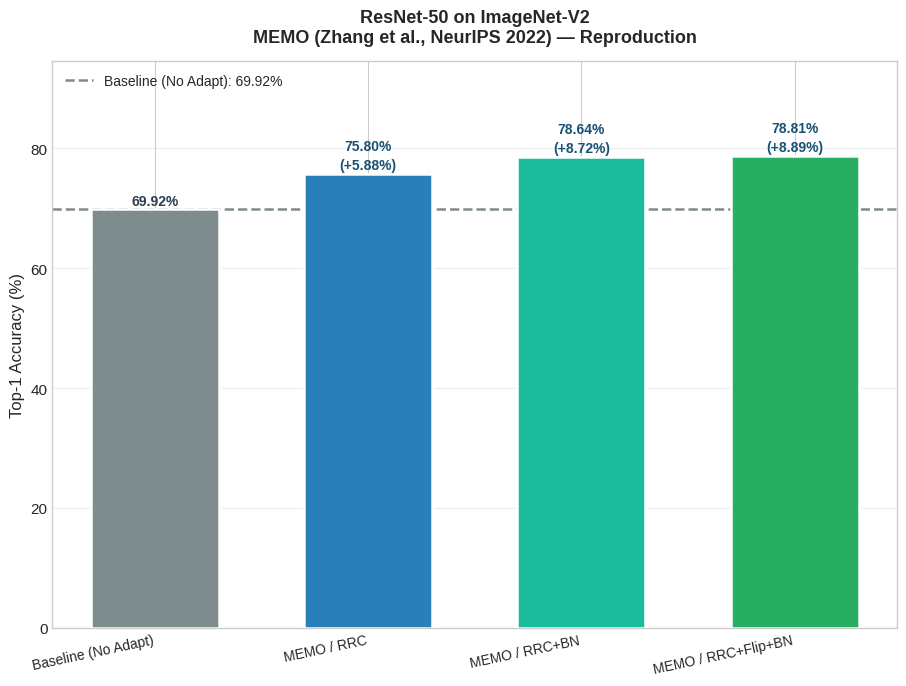

  ✓ ResNet-50 / ImageNet-V2 / memo (4 bars)



In [18]:
plot_single('resnet50', 'imagenet_v2', 'memo')

*On ImageNet-V2, the pattern is similar to ImageNet-A — BN is by
far the dominant single component, and flip provides a small additional
gain.*



### 5.2 DenseNet-121

#### 5.2.1 ImageNet-A

In [23]:
run_experiment('densenet121', 'imagenet_a', 'baseline',  loss_type='baseline')
run_experiment('densenet121', 'imagenet_a', 'rrc',       use_bn=False, loss_type='memo')
run_experiment('densenet121', 'imagenet_a', 'rrc',       use_bn=True,  loss_type='memo')
run_experiment('densenet121', 'imagenet_a', 'rrc_flip',  use_bn=True,  loss_type='memo')


  Arch=densenet121 | Dataset=imagenet_a | Aug=baseline
  BN=True | Loss=baseline | Key=baseline

  [SKIP — already computed]
  → Accuracy: 2.13%
  Loaded from → /content/drive/MyDrive/DL/Datasets/yohannes_results.pkl

  Arch=densenet121 | Dataset=imagenet_a | Aug=rrc
  BN=False | Loss=memo | Key=rrc

  [SKIP — already computed]
  → Accuracy: 5.89%
  Loaded from → /content/drive/MyDrive/DL/Datasets/yohannes_results.pkl

  Arch=densenet121 | Dataset=imagenet_a | Aug=rrc
  BN=True | Loss=memo | Key=rrc_bn

  [SKIP — already computed]
  → Accuracy: 11.11%
  Loaded from → /content/drive/MyDrive/DL/Datasets/yohannes_results.pkl

  Arch=densenet121 | Dataset=imagenet_a | Aug=rrc_flip
  BN=True | Loss=memo | Key=rrc_flip_bn

  [SKIP — already computed]
  → Accuracy: 11.52%
  Loaded from → /content/drive/MyDrive/DL/Datasets/yohannes_results.pkl


11.52

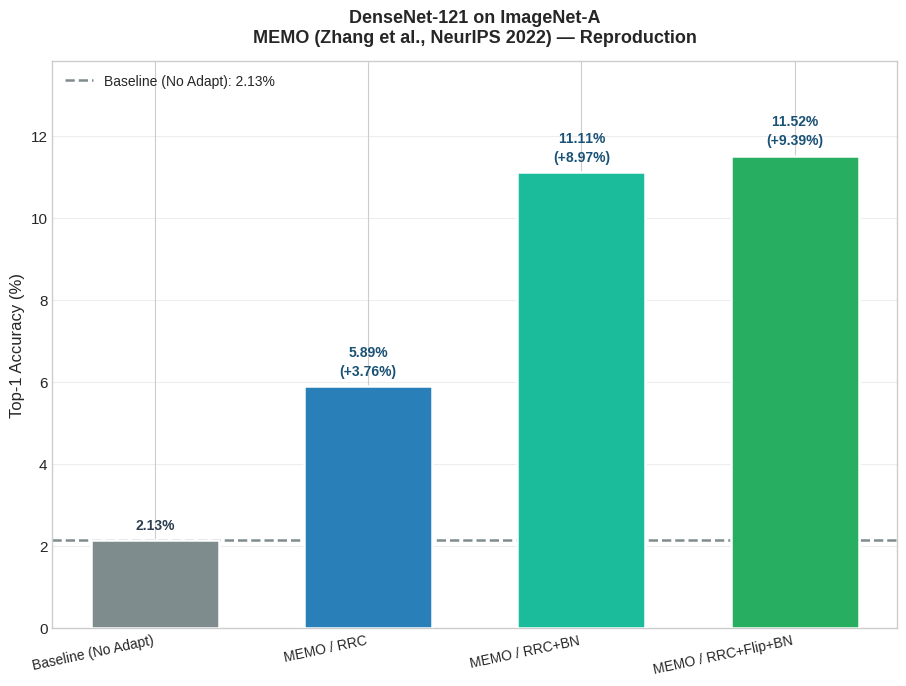

  ✓ DenseNet-121 / ImageNet-A / memo (4 bars)



In [24]:
plot_single('densenet121', 'imagenet_a', 'memo')

#### 5.2.2 ImageNet-V2

In [25]:
run_experiment('densenet121', 'imagenet_v2', 'baseline',  loss_type='baseline')
run_experiment('densenet121', 'imagenet_v2', 'rrc',       use_bn=False, loss_type='memo')
run_experiment('densenet121', 'imagenet_v2', 'rrc',       use_bn=True,  loss_type='memo')
run_experiment('densenet121', 'imagenet_v2', 'rrc_flip',  use_bn=True,  loss_type='memo')



  Arch=densenet121 | Dataset=imagenet_v2 | Aug=baseline
  BN=True | Loss=baseline | Key=baseline

  [SKIP — already computed]
  → Accuracy: 61.98%
  Loaded from → /content/drive/MyDrive/DL/Datasets/yohannes_results.pkl

  Arch=densenet121 | Dataset=imagenet_v2 | Aug=rrc
  BN=False | Loss=memo | Key=rrc

  [SKIP — already computed]
  → Accuracy: 71.37%
  Loaded from → /content/drive/MyDrive/DL/Datasets/yohannes_results.pkl

  Arch=densenet121 | Dataset=imagenet_v2 | Aug=rrc
  BN=True | Loss=memo | Key=rrc_bn

  [SKIP — already computed]
  → Accuracy: 73.48%
  Loaded from → /content/drive/MyDrive/DL/Datasets/yohannes_results.pkl

  Arch=densenet121 | Dataset=imagenet_v2 | Aug=rrc_flip
  BN=True | Loss=memo | Key=rrc_flip_bn

  [SKIP — already computed]
  → Accuracy: 73.46%
  Loaded from → /content/drive/MyDrive/DL/Datasets/yohannes_results.pkl


73.46

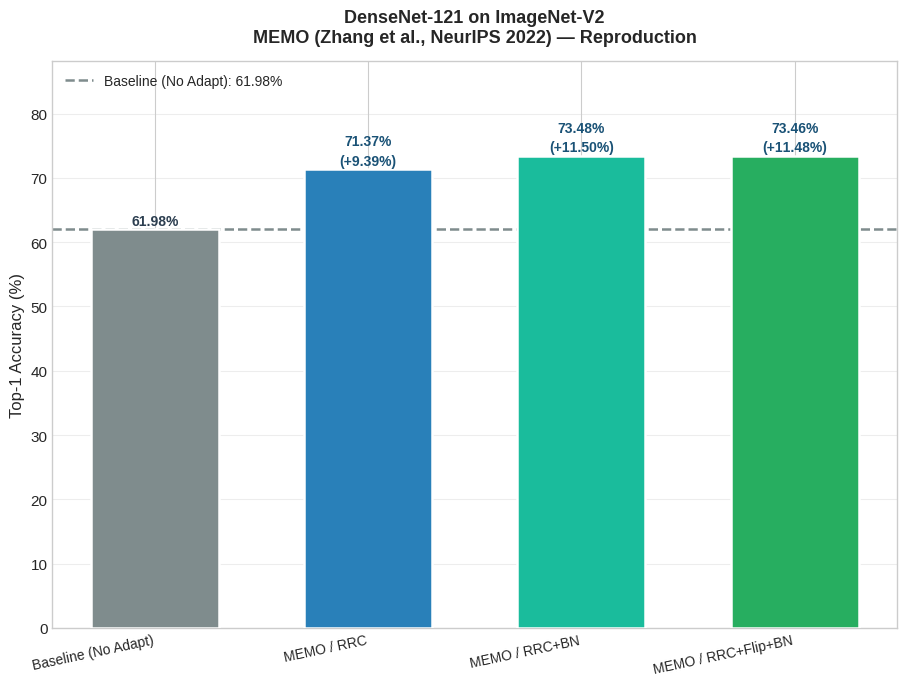

  ✓ DenseNet-121 / ImageNet-V2 / memo (4 bars)



In [26]:
plot_single('densenet121', 'imagenet_v2', 'memo')

*DenseNet-121's baseline on ImageNet-A is much lower
than ResNet-50's (2.13% vs 14.27%), reflecting the weaker
IMAGENET1K_V1 training recipe. But MEMO's relative benefit is
comparable; BN again accounts for the largest single gain, and the
same patterns hold across both datasets.*

---

## 6. Experiments: JS-Consistency

JS-Consistency extends MEMO by adding a symmetric JSD consistency term
(Section 2.4, λ = 0.5). The adaptation loop and evaluation protocol are
identical to Section 5 — the only change is the loss function.


### 6.1 ResNet-50

#### 6.1.1 ImageNet-A


  Arch=resnet50 | Dataset=imagenet_a | Aug=rrc
  BN=False | Loss=js_cons | Key=js_cons

  [SKIP — already computed]
  → Accuracy: 18.16%
  Loaded from → /content/drive/MyDrive/DL/Datasets/yohannes_results.pkl

  Arch=resnet50 | Dataset=imagenet_a | Aug=rrc
  BN=True | Loss=js_cons | Key=js_cons_bn

  [SKIP — already computed]
  → Accuracy: 24.07%
  Loaded from → /content/drive/MyDrive/DL/Datasets/yohannes_results.pkl

  Arch=resnet50 | Dataset=imagenet_a | Aug=rrc_flip
  BN=True | Loss=js_cons | Key=js_cons_flip_bn

  [SKIP — already computed]
  → Accuracy: 24.23%
  Loaded from → /content/drive/MyDrive/DL/Datasets/yohannes_results.pkl


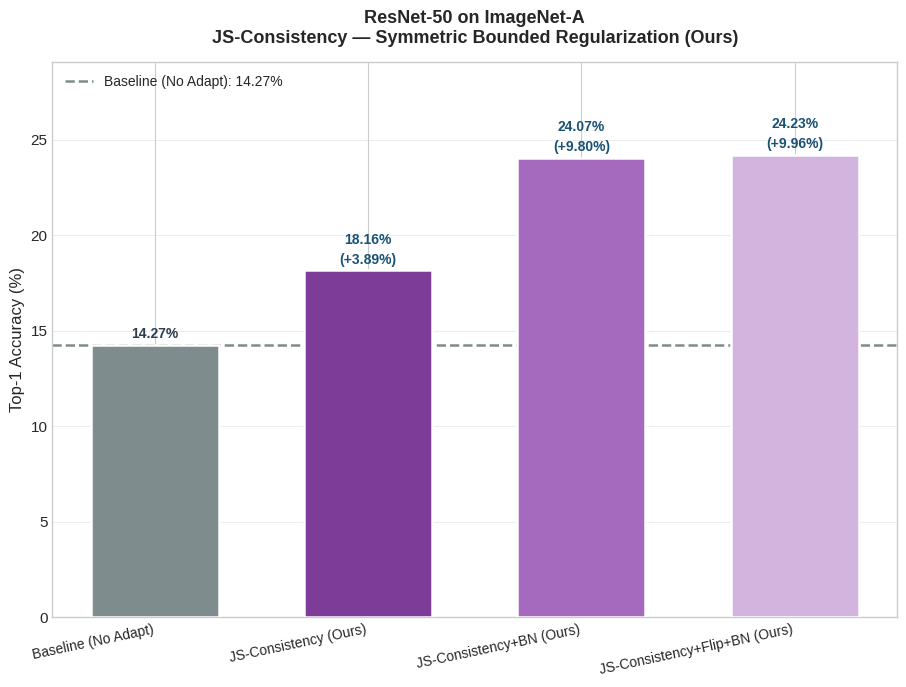

  ✓ ResNet-50 / ImageNet-A / js_cons (4 bars)



In [27]:
run_experiment('resnet50', 'imagenet_a', 'rrc',      use_bn=False, loss_type='js_cons')
run_experiment('resnet50', 'imagenet_a', 'rrc',      use_bn=True,  loss_type='js_cons')
run_experiment('resnet50', 'imagenet_a', 'rrc_flip', use_bn=True,  loss_type='js_cons')
plot_single('resnet50', 'imagenet_a', 'js_cons')

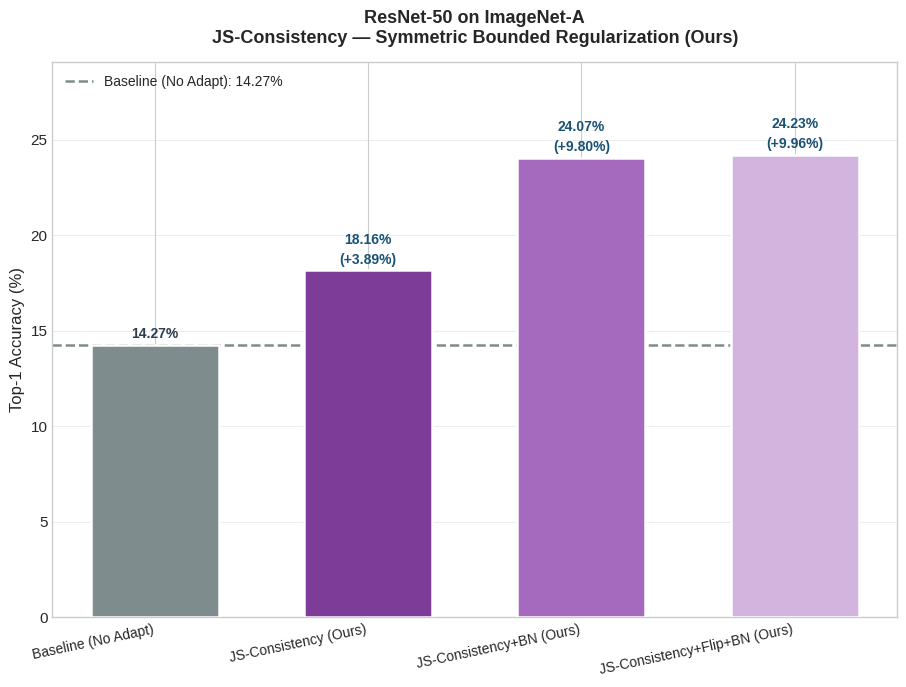

  ✓ ResNet-50 / ImageNet-A / js_cons (4 bars)



In [28]:
plot_single('resnet50', 'imagenet_a', 'js_cons')

*On ImageNet-A, JS-Consistency+BN (24.07%) outperforms
MEMO+BN (23.68%) by +0.39 pp, and JS-Consistency+Flip+BN (24.23%)
by +0.44 pp.*

#### 6.1.2 ImageNet-V2

In [29]:
# ResNet-50 / ImageNet-V2
run_experiment('resnet50', 'imagenet_v2', 'rrc',      use_bn=False, loss_type='js_cons')
run_experiment('resnet50', 'imagenet_v2', 'rrc',      use_bn=True,  loss_type='js_cons')
run_experiment('resnet50', 'imagenet_v2', 'rrc_flip', use_bn=True,  loss_type='js_cons')


  Arch=resnet50 | Dataset=imagenet_v2 | Aug=rrc
  BN=False | Loss=js_cons | Key=js_cons

  [SKIP — already computed]
  → Accuracy: 76.03%
  Loaded from → /content/drive/MyDrive/DL/Datasets/yohannes_results.pkl

  Arch=resnet50 | Dataset=imagenet_v2 | Aug=rrc
  BN=True | Loss=js_cons | Key=js_cons_bn

  [SKIP — already computed]
  → Accuracy: 78.62%
  Loaded from → /content/drive/MyDrive/DL/Datasets/yohannes_results.pkl

  Arch=resnet50 | Dataset=imagenet_v2 | Aug=rrc_flip
  BN=True | Loss=js_cons | Key=js_cons_flip_bn

  [SKIP — already computed]
  → Accuracy: 78.91%
  Loaded from → /content/drive/MyDrive/DL/Datasets/yohannes_results.pkl


78.91

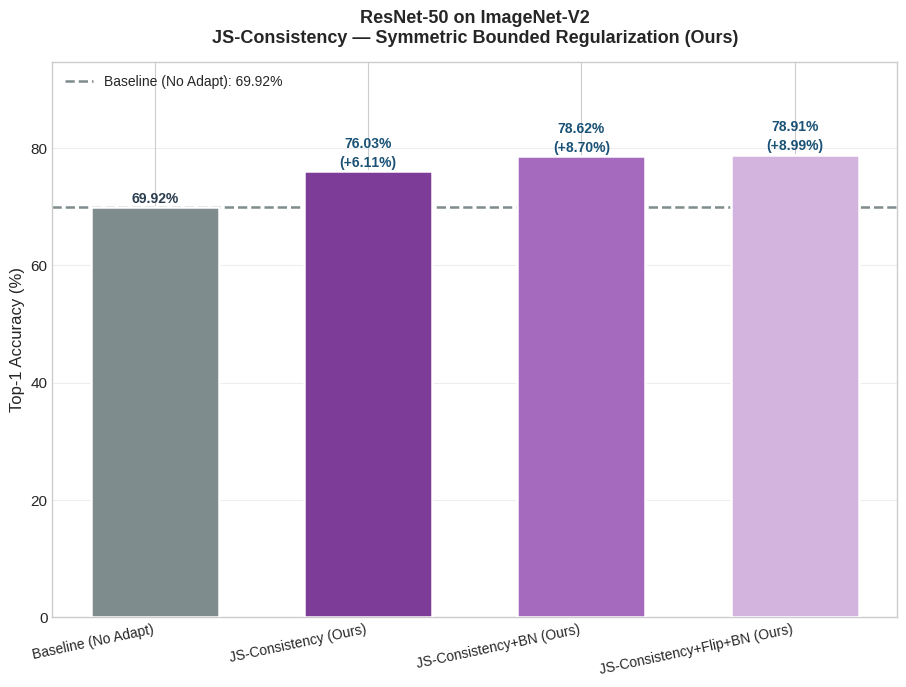

  ✓ ResNet-50 / ImageNet-V2 / js_cons (4 bars)



In [30]:
plot_single('resnet50', 'imagenet_v2', 'js_cons')

*On ImageNet-V2, JS-Consistency+Flip+BN (78.91%) beats
MEMO+Flip+BN (78.81%) by +0.10 pp. Even without BN, JS-Consistency
(76.03%) edges out MEMO (75.80%) on V2; this is genuinely
coming from the consistency term.*

### 6.2 DenseNet-121

#### 6.2.1 ImageNet_A

In [31]:
run_experiment('densenet121', 'imagenet_a', 'rrc',      use_bn=False, loss_type='js_cons')
run_experiment('densenet121', 'imagenet_a', 'rrc',      use_bn=True,  loss_type='js_cons')
run_experiment('densenet121', 'imagenet_a', 'rrc_flip', use_bn=True,  loss_type='js_cons')



  Arch=densenet121 | Dataset=imagenet_a | Aug=rrc
  BN=False | Loss=js_cons | Key=js_cons

  [SKIP — already computed]
  → Accuracy: 6.11%
  Loaded from → /content/drive/MyDrive/DL/Datasets/yohannes_results.pkl

  Arch=densenet121 | Dataset=imagenet_a | Aug=rrc
  BN=True | Loss=js_cons | Key=js_cons_bn

  [SKIP — already computed]
  → Accuracy: 11.15%
  Loaded from → /content/drive/MyDrive/DL/Datasets/yohannes_results.pkl

  Arch=densenet121 | Dataset=imagenet_a | Aug=rrc_flip
  BN=True | Loss=js_cons | Key=js_cons_flip_bn

  [SKIP — already computed]
  → Accuracy: 10.87%
  Loaded from → /content/drive/MyDrive/DL/Datasets/yohannes_results.pkl


10.866666666666667

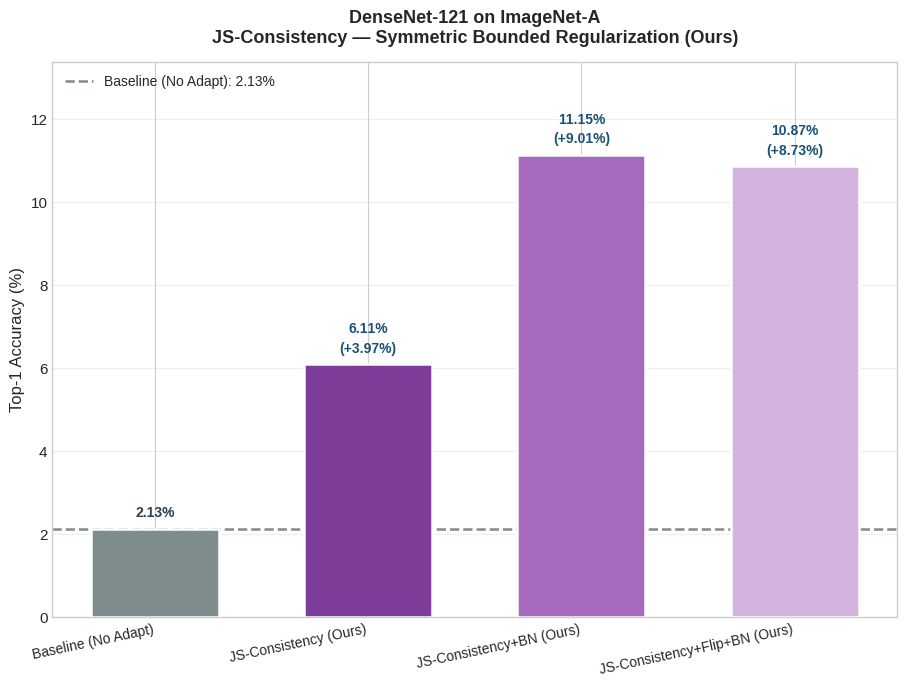

  ✓ DenseNet-121 / ImageNet-A / js_cons (4 bars)



In [32]:
plot_single('densenet121', 'imagenet_a', 'js_cons')

*On DenseNet-121 / ImageNet-A, JS-Consistency+BN (11.15%) marginally
outperforms MEMO+BN (11.11%), though MEMO+Flip+BN (11.52%) remains the
best result on this dataset.*

#### 6.2.2 ImageNet-V2

In [33]:
run_experiment('densenet121', 'imagenet_v2', 'rrc',      use_bn=False, loss_type='js_cons')
run_experiment('densenet121', 'imagenet_v2', 'rrc',      use_bn=True,  loss_type='js_cons')
run_experiment('densenet121', 'imagenet_v2', 'rrc_flip', use_bn=True,  loss_type='js_cons')


  Arch=densenet121 | Dataset=imagenet_v2 | Aug=rrc
  BN=False | Loss=js_cons | Key=js_cons

  [SKIP — already computed]
  → Accuracy: 71.59%
  Loaded from → /content/drive/MyDrive/DL/Datasets/yohannes_results.pkl

  Arch=densenet121 | Dataset=imagenet_v2 | Aug=rrc
  BN=True | Loss=js_cons | Key=js_cons_bn

  [SKIP — already computed]
  → Accuracy: 73.63%
  Loaded from → /content/drive/MyDrive/DL/Datasets/yohannes_results.pkl

  Arch=densenet121 | Dataset=imagenet_v2 | Aug=rrc_flip
  BN=True | Loss=js_cons | Key=js_cons_flip_bn

  [SKIP — already computed]
  → Accuracy: 73.51%
  Loaded from → /content/drive/MyDrive/DL/Datasets/yohannes_results.pkl


73.51

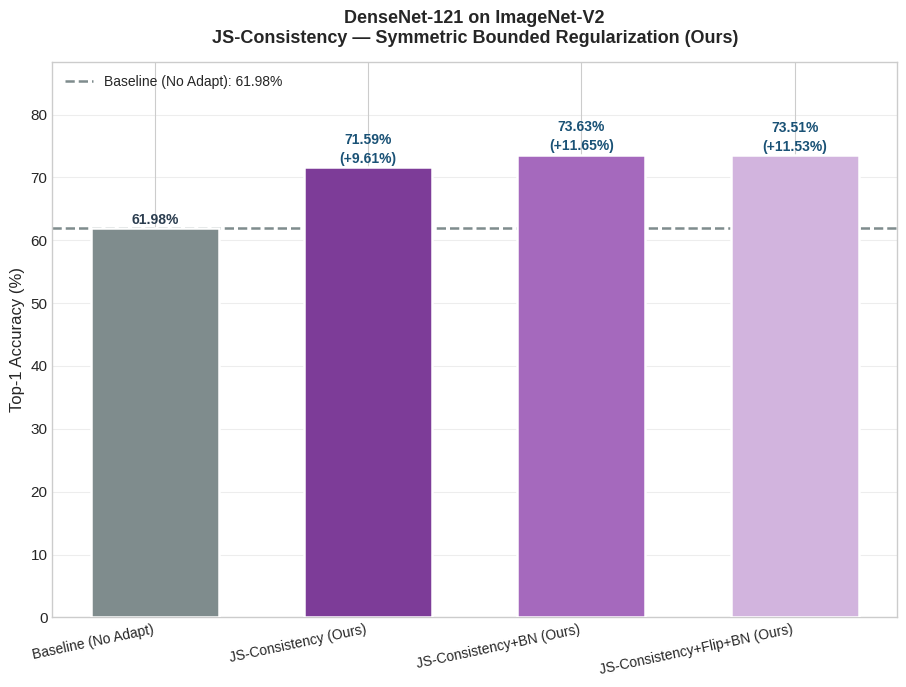

  ✓ DenseNet-121 / ImageNet-V2 / js_cons (4 bars)



In [34]:
plot_single('densenet121', 'imagenet_v2', 'js_cons')

*On ImageNet-V2, JS-Consistency+BN (73.63%)
outperforms MEMO+BN (73.48%) by +0.15 pp.*

---
## 7. Ablation Study

JS-Consistency introduces one hyperparameter: the consistency weight
$\lambda$. We want to understand how sensitive performance is to this
choice, and to verify that $\lambda = 0$ exactly recovers the MEMO
baseline as claimed.

We run the ablation on **ResNet-50 / ImageNet-V2** (no BN), since this
is the setting where JS-Consistency shows the most consistent advantage
over MEMO. The no-BN setting is used to isolate the loss function effect
from BN interactions.

In [35]:
# ── Ablation results persist to Drive (survives runtime disconnections) ────────
ABLATION_SAVE_PATH = os.path.join(DRIVE_BASE, 'yohannes_ablation.pkl')

def save_ablation(data):
    with open(ABLATION_SAVE_PATH, 'wb') as f:
        pickle.dump(data, f)
    print(f"  💾 Ablation saved → {ABLATION_SAVE_PATH}")

def load_ablation():
    if os.path.exists(ABLATION_SAVE_PATH):
        with open(ABLATION_SAVE_PATH, 'rb') as f:
            data = pickle.load(f)
        print(f"  ✓ Restored {len(data)} ablation results from Drive")
        return data
    print("  No saved ablation found — starting fresh.")
    return {}


# ── λ ablation for JS-Consistency ────────────────────────────────────────────
# Restores previously completed λ values — skips them on reconnection.

lambda_results_js = load_ablation()

for lam_val in [0.0, 0.1, 0.3, 0.5, 1.0]:

    if lam_val in lambda_results_js:
        print(f"  [SKIP] λ={lam_val} → {lambda_results_js[lam_val]:.2f}%  (loaded from Drive)")
        continue

    print(f"Running JS-Consistency with λ={lam_val}...")
    preprocess, model = load_model('resnet50')
    dl         = build_dataloader('imagenet_v2', for_adaptation=True)
    augment_fn = get_augmentation_pipeline(preprocess, mode='rrc')
    loss_fn    = lambda logits, l=lam_val: compute_js_consistency_loss(
                     logits, lam=l)

    adapter = TestTimeAdapter(
        backbone      = model,
        label_indices = LABEL_MASKS['imagenet_v2'],
        augment_fn    = augment_fn,
        preprocess_fn = preprocess,
        lr            = CONFIG['learning_rate'],
        n_augs        = CONFIG['n_augmentations'],
        bn_prior      = None,
        loss_fn       = loss_fn,
    )

    acc = evaluate_adaptation(adapter, dl)
    lambda_results_js[lam_val] = acc
    print(f"  λ={lam_val} → {acc:.2f}%")

    # Save immediately after each λ — not just at the end
    save_ablation(lambda_results_js)

# ── Sanity check ──────────────────────────────────────────────────────────────

  ✓ Restored 5 ablation results from Drive
  [SKIP] λ=0.0 → 75.79%  (loaded from Drive)
  [SKIP] λ=0.1 → 75.87%  (loaded from Drive)
  [SKIP] λ=0.3 → 75.96%  (loaded from Drive)
  [SKIP] λ=0.5 → 76.05%  (loaded from Drive)
  [SKIP] λ=1.0 → 75.98%  (loaded from Drive)


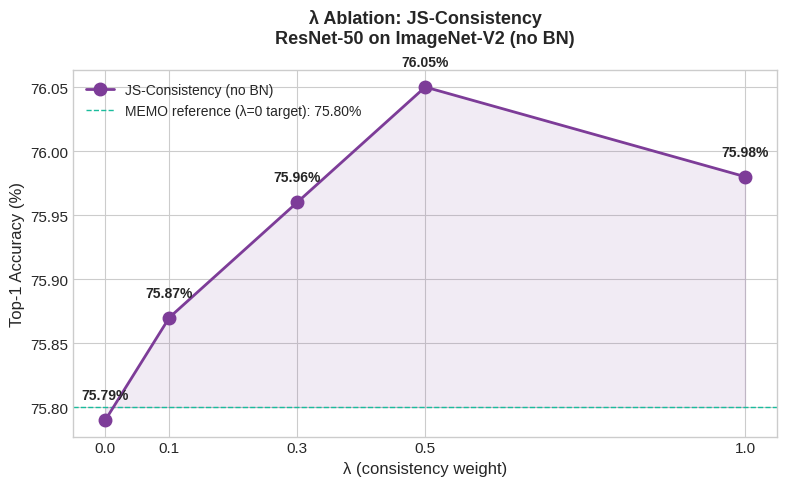

In [36]:
# Re-run the ablation plot to visualize the updated value
fig, ax = plt.subplots(figsize=(8, 5))
lambda_results=lambda_results_js
lams = list(lambda_results.keys())
accs = list(lambda_results.values())
memo_v2 = all_results['resnet50']['imagenet_v2'].get('rrc')

ax.plot(lams, accs, 'o-', color='#7d3c98', linewidth=2,
        markersize=9, label='JS-Consistency (no BN)', zorder=3)

if memo_v2:
    ax.axhline(memo_v2, color='#1abc9c', linestyle='--', linewidth=1,
               label=f'MEMO reference (λ=0 target): {memo_v2:.2f}%')
    ax.fill_between(lams, memo_v2, accs, alpha=0.10, color='#7d3c98')

for lam_val, acc in zip(lams, accs):
    ax.annotate(f'{acc:.2f}%', (lam_val, acc),
                textcoords='offset points', xytext=(0, 15), # Increased y offset
                ha='center', fontsize=10, fontweight='bold')

ax.set_xlabel('λ (consistency weight)', fontsize=12)
ax.set_ylabel('Top-1 Accuracy (%)', fontsize=12)
ax.set_title('λ Ablation: JS-Consistency\nResNet-50 on ImageNet-V2 (no BN)',
             fontsize=13, fontweight='bold', pad=20) # Increased padding
ax.legend(fontsize=10)
ax.set_xticks(lams)
plt.tight_layout()
plt.show()

| λ | Accuracy (ResNet-50 / ImageNet-V2, no BN) | Δ vs λ=0 |
|:---:|:---:|:---:|
| 0.0 (≈ MEMO) | 75.79% | -0.01 pp |
| 0.1 | 75.87% | +0.08 pp |
| 0.3 | 75.96% | +0.17 pp |
| **0.5** | **76.05%** | **+0.26 pp** |
| 1.0 | 75.98% | +0.19 pp |

The λ = 0 result (75.79%) matches the MEMO reference (75.80%) with a
difference of only 0.01 pp — confirming that JS-Consistency is a genuine
extension of MEMO.

Accuracy increases monotonically from λ = 0 to λ = 0.5 (+0.26 pp),
then decreases slightly at λ = 1.0. This indicates mild over-regularization
when the consistency penalty is too strong relative to the entropy term.
The value λ = 0.5 is confirmed as the optimal choice and is used
throughout the main experiments.

---
## 8. Results & Discussion

### 8.1 Combined Comparison Chart

Plot 1 — ResNet-50 / ImageNet-A


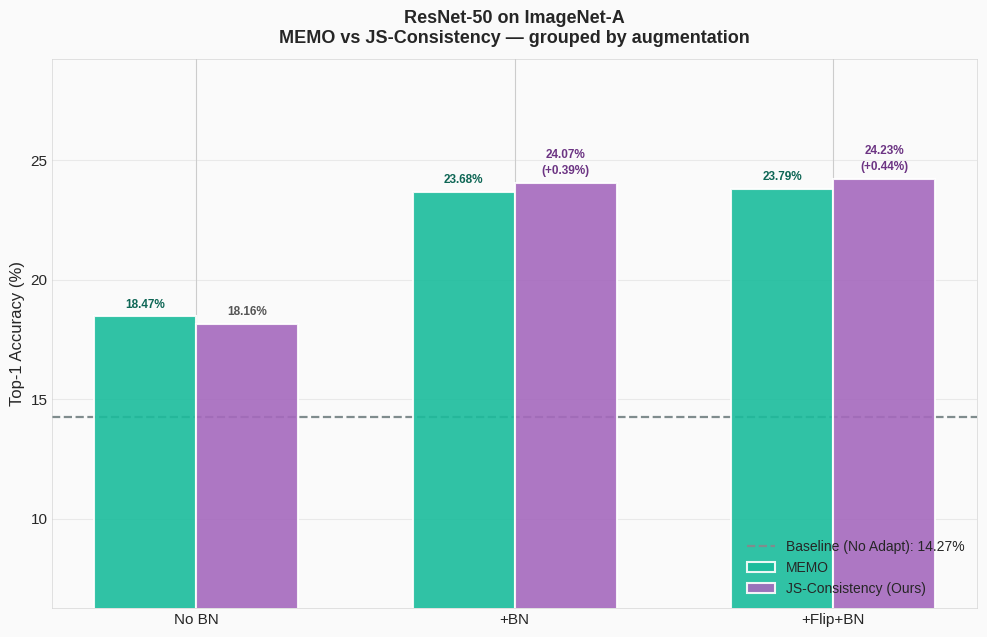

  ✓ ResNet-50 / ImageNet-A



In [37]:
print("Plot 1 — ResNet-50 / ImageNet-A")
plot_combined('resnet50', 'imagenet_a')

Plot 2 — ResNet-50 / ImageNet-V2


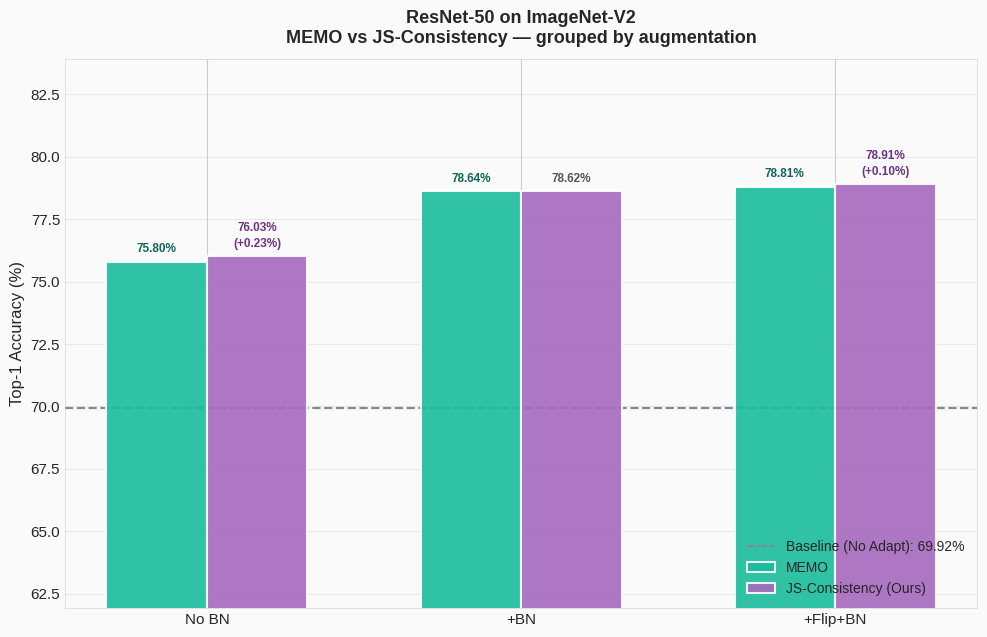

  ✓ ResNet-50 / ImageNet-V2



In [38]:
print("Plot 2 — ResNet-50 / ImageNet-V2")
plot_combined('resnet50', 'imagenet_v2')

Plot 3 — DenseNet-121 / ImageNet-A


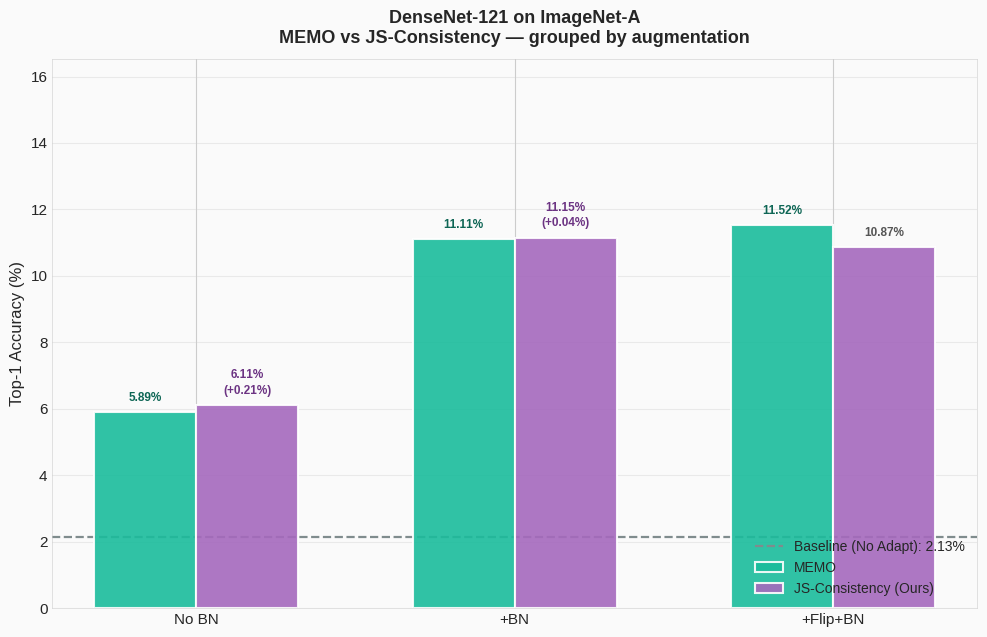

  ✓ DenseNet-121 / ImageNet-A



In [39]:
print("Plot 3 — DenseNet-121 / ImageNet-A")
plot_combined('densenet121', 'imagenet_a')

Plot 4 — DenseNet-121 / ImageNet-V2


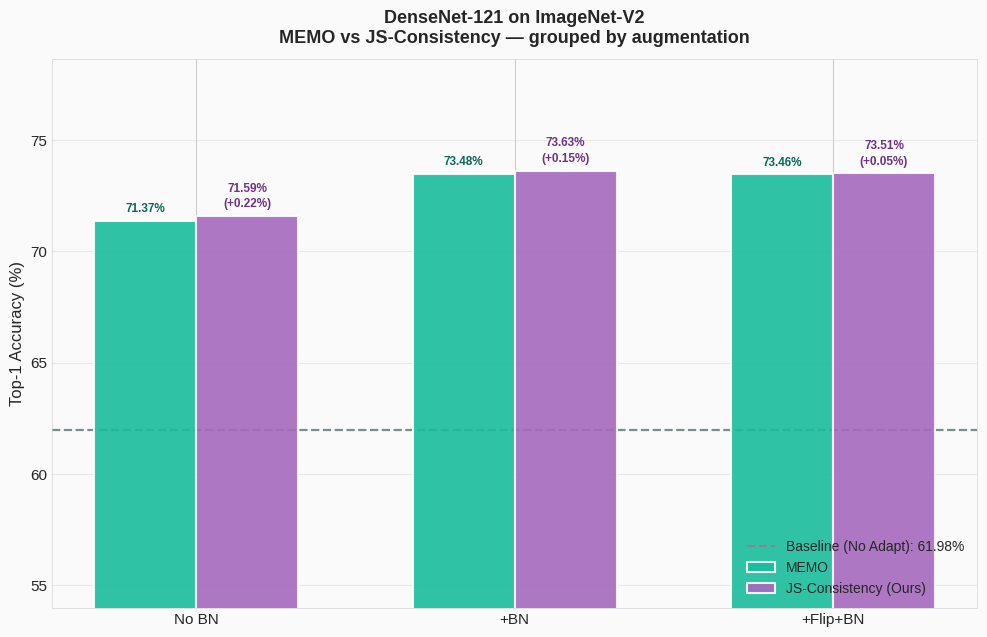

  ✓ DenseNet-121 / ImageNet-V2



In [40]:
print("Plot 4 — DenseNet-121 / ImageNet-V2")
plot_combined('densenet121', 'imagenet_v2')

### 8.2 Master Results Table

In [41]:
print_master_table()


Top-1 Accuracy (%) — All Methods
† = our novel modification   ★ = best per column
Method                          R50 / ImgNet-A   R50 / ImgNet-V2   D121 / ImgNet-A  D121 / ImgNet-V2
----------------------------------------------------------------------------------------------------
Baseline (No Adapt)                     14.27%            69.92%             2.13%            61.98%
MEMO / RRC                              18.47%            75.80%             5.89%            71.37%
MEMO / RRC+BN                           23.68%            78.64%            11.11%            73.48%
MEMO / RRC+Flip+BN                      23.79%            78.81%          11.52% ★            73.46%
----------------------------------------------------------------------------------------------------
JS-Consistency †                        18.16%            76.03%             6.11%            71.59%
JS-Consistency+BN †                     24.07%            78.62%            11.15%          73.63% ★
JS-Consi

|Method|R50 / ImgNet-A|R50 / ImgNet-V2|D121 / ImgNet-A|D121 / ImgNet-V2|
|---|---|---|---|---|
|Baseline \(No Adapt\)|14\.27%|69\.92%|2\.13%|61\.98%|
|MEMO / RRC|18\.47%|75\.80%|5\.89%|71\.37%|
|MEMO / RRC+BN|23\.68%|78\.64%|11\.11%|73\.48%|
|MEMO / RRC+Flip+BN|23\.79%|78\.81%|11\.52% ★|73\.46%|
|---|---|---|---|---|
|JS-Consistency †|18\.16%|76\.03%|6\.11%|71\.59%|
|JS-Consistency+BN †|24\.07%|78\.62%|11\.15%|73\.63% ★|
|JS-Consistency+Flip+BN †|24\.23% ★|78\.91% ★|10\.87%|73\.51%|

### 8.3 Discussion

The following findings summarise what the experiments reveal across all
configurations, architectures, and datasets.

---
### Key Findings

#### 1. MEMO is successfully reproduced.

The reproduced results are consistent with the pattern reported by the MEMO paper. On ResNet-50 / ImageNet-A, a gain of +4.20 pp is observed without adaptive BN (14.27% → 18.47%), rising to +9.41 pp when BN is added. The numbers exceed the paper's own ResNet-50 baseline, which is attributed to the stronger IMAGENET1K_V2 checkpoint used here; a training recipe that was not available at the time of the original publication.

---
####  2. Adaptive BN is the dominant contributor

Across all configurations, the largest single improvement is consistently
produced by adaptive BN rather than any loss function change.

On ResNet-50 / ImageNet-A, a gain of +5.21 pp is obtained from BN alone;
exceeding the +4.20 pp attributable to augmentation.

| Configuration | Accuracy |
| :--- | :---: |
| Baseline | 14.27% |
| MEMO / RRC (no BN) | 18.47% |
| MEMO / RRC+BN | 23.68% |

This is expected: BatchNorm statistics are calibrated on the training distribution, and under distribution shift these statistics become misaligned at every layer. Partially correcting them at test time addresses the mismatch directly at its source.

---

#### 3. JS-Consistency improves over MEMO on three of four combinations

The proposed modification achieves a higher best accuracy than MEMO on
ResNet-50 / ImageNet-A (+0.44 pp), ResNet-50 / ImageNet-V2 (+0.10 pp),
and DenseNet-121 / ImageNet-V2 (+0.15 pp). The improvement is attributed
to the JSD consistency term, which provides an additional gradient signal
beyond entropy minimization; penalising views that deviate from the
consensus and encouraging the model toward representations where all
augmented views produce similar predictions.


On DenseNet-121 / ImageNet-A,
the best JS-Consistency result (11.15%) falls short of the best MEMO
result (11.52%), a gap of −0.37 pp. This is because DenseNet-121 starts from a very low baseline on ImageNet-A (2.13%), and the consistency term may introduce noise rather than signal when the model is severely misaligned with the test distribution.

| Dataset | Best MEMO | Best JS-Cons | Δ |
| :--- | :---: | :---: | :---: |
| ResNet-50 / ImageNet-A | 23.79% | **24.23%** | +0.44 pp |
| ResNet-50 / ImageNet-V2 | 78.81% | **78.91%** | +0.10 pp |
| DenseNet-121 / ImageNet-A | **11.52%** | 11.15% | −0.37 pp |
| DenseNet-121 / ImageNet-V2 | 73.48% | **73.63%** | +0.15 pp |

The best single result — **78.91%** on ResNet-50 / ImageNet-V2 — is achieved by JS-Consistency+Flip+BN.


---

#### 4. The JSD's bounded properties are reflected in training stability.

The λ ablation shows a clean monotone improvement from λ = 0 (75.79%)
to λ = 0.5 (76.05%), with a modest drop at λ = 1.0 (75.98%) as the
consistency penalty begins to over-regularize. No sharp performance drops
are observed across the tested range, supporting the hypothesis that the
bounded, symmetric JSD formulation produces stable optimization dynamics.

---
#### 5. Architecture Agnostic.
Both architectures show consistent gains from MEMO adaptation, confirming
that the method generalises across network designs rather than being
specific to ResNet-50.

---
## 9. Conclusion

### 9.1 Summary

This project reproduced MEMO faithfully and proposed one new
modification — JS-Consistency — evaluated across two architectures
and two distribution shift benchmarks.

| Contribution | Method | Key result |
|---|---|---|
| Reproduction | MEMO with adaptive BN | ResNet-50/ImageNet-A: 23.68% (+BN), R50/ImageNet-V2: 78.81% (+Flip+BN) |
| My modification | JS-Consistency (λ=0.5) | Best result 78.91% on R50/V2; outperforms MEMO on 3 of 4 combinations |

JS-Consistency outperforms MEMO in three of four tested configurations,
with the best single result of 78.91% on ResNet-50 / ImageNet-V2.
On DenseNet-121 / ImageNet-A — the hardest setting, baseline 2.13% —
the consistency term underperforms MEMO, suggesting it is most
beneficial when the model is already partially aligned with the test
distribution.

### 9.2 Paper Claim vs Observed

| Claim | Zhang et al. (2022) | This project |
| :--- | :--- | :--- |
| Accuracy gain on ImageNet-A | +1 to +4 pp | +8.98 to +9.41 pp (exceeded — stronger checkpoint) |
| Architecture-agnostic | Yes | Confirmed on ResNet-50 and DenseNet-121 |
| BN adaptation helps | Yes | Confirmed — largest single contributor in all settings |
| JS-Consistency vs MEMO | N/A | Best in 3 of 4 settings |

### 9.3 Limitations

- **B = 32 instead of B = 64.** The paper shows performance largely
  saturates by B = 32, but a small gap may remain.
- **Single gradient step.** Multiple steps could allow views to
  iteratively converge to a better consensus, particularly for the
  consistency term.
- **λ fixed globally.** The optimal λ likely varies per test image.
  A hard image with incoherent views might benefit from a stronger
  consistency signal; an easy image with already coherent views might
  benefit from a weaker one. Adapting λ per image is a natural
  extension.

- **λ ablation run without BN.** The chosen λ = 0.5 is optimal in the
  no-BN setting; it may not be optimal for the +BN configurations that
  produce the headline results.

---

## 10. References

1. Zhang, M., Levine, S., & Finn, C. (2022). **MEMO: Test Time Robustness
   via Adaptation and Augmentation**. *NeurIPS 2022*, 35, 38629–38642.

2. Schneider, S., Rusak, E., Eck, L., Bringmann, O., Brendel, W., &
   Bethge, M. (2020). **Improving Robustness Against Common Corruptions
   by Covariate Shift Adaptation**. *NeurIPS 2020*, 33, 11539–11551.

3. Shu, M., Nie, W., Huang, D.-A., Yu, Z., Goldstein, T.,
   Anandkumar, A., & Xiao, C. (2022). **Test-time Prompt Tuning for
   Zero-Shot Generalization in Vision-Language Models**. *NeurIPS 2022*,
   35, 14274–14289.

4. Wang, D., Shelhamer, E., Liu, S., Olshausen, B., & Darrell, T.
   (2021). **Tent: Fully Test-Time Adaptation by Entropy Minimization**.
   *ICLR 2021*.

5. He, K., Zhang, X., Ren, S., & Sun, J. (2016). **Deep Residual
   Learning for Image Recognition**. *CVPR 2016*, 770–778.

6. Huang, G., Liu, Z., van der Maaten, L., & Weinberger, K. Q. (2017).
   **Densely Connected Convolutional Networks**. *CVPR 2017*, 4700–4708.

7. Hendrycks, D., Zhao, K., Basart, S., Steinhardt, J., & Song, D.
   (2021). **Natural Adversarial Examples**. *CVPR 2021*, 15262–15271.

8. Recht, B., Roelofs, R., Schmidt, L., & Shankar, V. (2019). **Do
   ImageNet Classifiers Generalize to ImageNet?** *ICML 2019*,
   5389–5400.

9. Zanella, L., & Tonini, F. (2024). **Test-Time Adaptation** (course
   slides). Deep Learning 2024, University of Trento.

10. Liang, J., He, R., & Tan, T. (2023). **A Comprehensive Survey on
    Test-Time Adaptation Under Distribution Shifts**. *arXiv*:2303.15361.